# Latent Variables and Visualisation

### [Neil D. Lawrence](http://inverseprobability.com), University of

Cambridge

### 2025-09-23

**Abstract**: This lecture introduces different approaches to
discovering latent structure in data. We begin by examining clustering
as a discrete approach to finding latent structure, then explore why
high dimensional data often has simpler underlying continuous
representations. This motivates our introduction to Principal Component
Analysis (PCA) as a fundamental approach to continuous latent variable
modeling.

$$
$$

<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!---->
<!-- Do not edit this file locally. -->
<!-- Do not edit this file locally. -->
<!-- The last names to be defined. Should be defined entirely in terms of macros from above-->
<!--

-->

## ML Foundations Course Notebook Setup

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_mlfc/includes/mlfc-notebook-setup.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_mlfc/includes/mlfc-notebook-setup.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We install some bespoke codes for creating and saving plots as well as
loading data sets.

In [ ]:
%%capture
%pip install notutils
%pip install git+https://github.com/lawrennd/ods.git
%pip install git+https://github.com/lawrennd/mlai.git

In [1]:
import notutils
import pods
import mlai
import mlai.plot as plot

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 22})

<!--setupplotcode{import seaborn as sns
sns.set_style('darkgrid')
sns.set_context('paper')
sns.set_palette('colorblind')}-->

## High Dimensional Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/high-dimensional-data.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/high-dimensional-data.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

To introduce how to think about high dimensional data, we will first of
all introduce a hand written digit from the U.S. Postal Service
handwritten digit data set (originally collected from scanning
enveolopes) and used in the first convolutional neural network paper
(Le Cun et al., 1989).

Le Cun et al. (1989) downscaled the images to $16 \times 16$, here we
use an image at the original scale, containing 64 rows and 57 columns.
Since the pixels are binary, and the number of dimensions is 3,648, this
space contains $2^{3,648}$ possible images. So this space contains a lot
more than just one digit.

## USPS Samples

If we sample from this space, taking each pixel independently from a
probability which is given by the number of pixels which are ‘on’ in the
original image, over the total number of pixels, we see images that look
nothing like the original digit.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import mlai
import pods

|    Downloading   0.003MB     |
|>|


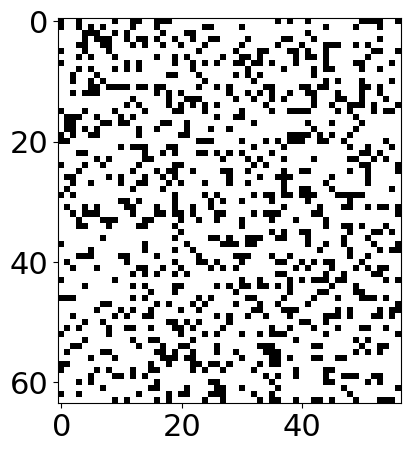

In [4]:
fig, ax = plt.subplots(figsize=(5,5))

pods.access.download_url("https://github.com/lawrennd/slides/raw/gh-pages/diagrams/ml/br1561_6.3.pgm",
                         store_directory="./ml")
six_image = mlai.load_pgm("br1561_6.3.pgm", directory ="./ml")
rows = six_image.shape[0]
cols = six_image.shape[1]
      
ax.imshow(six_image,interpolation='none').set_cmap('gray')
mlai.write_figure("dem_six000.png", directory="./dimred/")
for i in range(3):
    rand_image = np.random.rand(rows, cols)<((six_image>0).sum()/float(rows*cols))
    ax.imshow(rand_image,interpolation='none').set_cmap('gray')
    mlai.write_figure('dem_six{i:0>3}.png'.format(i=i+1), directory="./dimred/")

In [5]:
from ipywidgets import IntSlider
import notutils as nu

In [6]:
nu.display_plots('dem_six{counter:0>3}.png', directory='./dimred', counter=IntSlider(0, 0, 3, 1))

interactive(children=(IntSlider(value=0, description='counter', max=3), Output()), _dom_classes=('widget-inter…

<table>
<tr>
<td width="30%">

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/dem_six000.png" style="width:100%">

</td>
<td width="30%">

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/dem_six001.png" style="width:100%">

</td>
<td width="30%">

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/dem_six002.png" style="width:100%">

</td>
</tr>
</table>

Figure: <i>Even if we sample every nano second from now until the end of
the universe we won’t see the original six again.</i>

## Simple Model of Digit

An independent pixel model for this digit doesn’t seem sensible. The
total space is enormous, and yet the space occupied by the type of data
we’re interested in is relatively small.

## Probability of Random Image Generation

Let’s consider a simple model for handwritten 6s. We model each pixel
independently with a binomial distribution. Each pixel is the result of
a single binomial trial, known as a Bernoulli distribution. $$
p(\mathbf{ y}) = \prod_{j=1}^d\pi^{y_j}
(1-\pi)^{(1-y_j)},
$$ where the probability across pixels are taken to be independent and
are governed by the same probability of being on, $\pi$. The maximum
likelihood solution for this parameter is given by the number of pixels
that are on in the data point divided by the total number of pixels $$
\pi= \frac{849}{3,648}.
$$ The probability of recovering the original six in any given sample is
then given by $$
p(\mathbf{ y}=\text{given\,image}) = \pi^{849}(1-\pi)^{3,648 - 849
}=2.67\times10^{-860}.
$$

This demonstrates why independent pixel models are inadequate for
high-dimensional data. The probability of generating the original image
by random sampling is so small ($2.67 \times 10^{-860}$) that it’s
effectively impossible. This highlights the need for more sophisticated
models that capture the underlying structure and dependencies in the
data.

Consider a different type of model. One where we take a prototype six
and we rotate it left and right to create new data.

In [7]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [8]:
from skimage.transform import rotate
import numpy as np
import mlai

In [9]:
# Load in the six
six_image = mlai.load_pgm('br1561_6.3.pgm', directory ='./ml')/255.0

# Pad out to 64 columns
rows = six_image.shape[0]
six_image = np.hstack([np.ones((rows, 3)), six_image, np.ones((rows, 4))])
dim_one = np.asarray(six_image.shape)
angles = range(360)
Y = np.zeros((len(angles), np.prod(dim_one)))
for i, angle in enumerate(angles):
    rot_image = rotate(six_image, angle, cval=1.0)
    dim_two = np.asarray(rot_image.shape)
    start = [int(round((dim_two[0] - dim_one[0])/2)), int(round((dim_two[1] - dim_one[1])/2))]
    crop_image = rot_image[start[0]+np.array(range(dim_one[0])), :][:, start[1]+np.array(range(dim_one[1]))]
    Y[i, :] = crop_image.flatten()

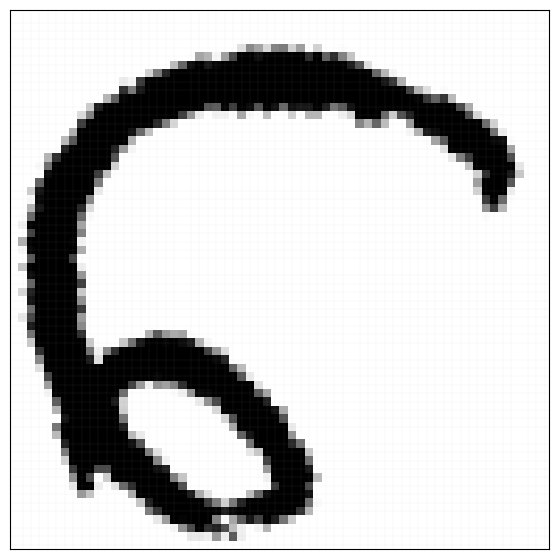

In [10]:
fig, ax = plt.subplots(figsize=plot.big_figsize)

show_angles = [31, 11, 350, 330, 310, 290]
for i, angle in enumerate(show_angles):
    ax.imshow(np.reshape(Y[angle, :], dim_one),interpolation='none').set_cmap('gray')
    ax.set_xticks(range(dim_one[1]), minor=True)  # Every column
    ax.set_yticks(range(dim_one[0]), minor=True)  # Every row
    ax.grid(True, which='minor', alpha=0.5, linewidth=0.1)
    ax.tick_params(which='minor', size=0)  
    ax.tick_params(which='major', size=0)  
    ax.tick_params(labelbottom=False, labelleft=False)  
    
    mlai.write_figure(f"six_rotate{i:0>3}.svg", directory="./dimred/")

In [11]:
import notutils as nu

In [12]:
nu.display_plots('six_rotate{counter:0>3}.svg', directory='./dimred', counter=(0, 5))

interactive(children=(IntSlider(value=2, description='counter', max=5), Output()), _dom_classes=('widget-inter…

<table>
<tr>
<td width="30%">

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/six_rotate001.svg" class="" width="100%" style="vertical-align:middle;">

</td>
<td width="30%">

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/six_rotate003.svg" class="" width="100%" style="vertical-align:middle;">

</td>
<td width="30%">

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/six_rotate005.png" style="width:100%">

</td>
</tr>
</table>

Figure: <i>Rotate a prototype six to form a set of plausible sixes.</i>

## PCA of Rotated Sixes

Now let’s perform PCA on the rotated sixes to see how the data projects
into a lower dimensional space. The rotated data should lie
approximately on a one-dimensional manifold corresponding to the
rotation angle.

In [13]:
import numpy as np

In [14]:
# Center the data
Y_centered = Y - np.mean(Y, axis=0)

# SVD of the centered data matrix (360 x 3648)
U, s, Vt = np.linalg.svd(Y_centered, full_matrices=False)

# Eigenvalues are s^2 / n 
eigenvalues = s**2 / Y.shape[0]

# Project data onto principal components
# Standard approach: X = U @ diag(s) gives the projections
X = U @ np.diag(s)

In [15]:
def plot_pca_manifold(X, Y, dims, filename, show_every=20, angle_ranges=None, colors=None):
    """Plot PCA manifold with optional angle range filtering"""
    fig, ax = plt.subplots(figsize=plot.big_figsize)
    h_points = ax.plot(X[:, 0], X[:, 1], 'rx', linewidth=2, alpha=0.7)[0]
    show_indices = range(0, len(X), show_every)  # Every 20 degrees
    if angle_ranges is None:
        # Plot all points
        show_indices = range(0, len(X), show_every)  # Every 20 degrees
    else:
        # Plot specific angle ranges
        h_points.set_data([], [])
        for i, (start, end, color) in enumerate(zip(angle_ranges['starts'], 
                                                   angle_ranges['ends'], 
                                                   colors or ['r', 'b'])):
            mask = (np.arange(len(X)) >= start) & (np.arange(len(X)) < end)
            ax.plot(X[mask, 0], X[mask, 1], f'{color}x', linewidth=2, alpha=0.7)
        
        # Show images only in specified ranges
        orig_show = show_indices
        show_indices = []
        for start, end in zip(angle_ranges['starts'], angle_ranges['ends']):
            for ind in orig_show:
                if ind >= start and ind <= end:
                    show_indices.append(ind)
    
    # Add small image insets
    for i in show_indices:
        if i < len(X):
            ax.scatter(X[i, 0], X[i, 1], s=50)
            
            # Calculate position for small image
            x_pos, y_pos = X[i, 0], X[i, 1]
            
            # Get plot limits and convert to figure coordinates
            x_min, x_max = ax.get_xlim()
            y_min, y_max = ax.get_ylim()
            
            x_fig = 0.1 + 0.8 * (x_pos - x_min) / (x_max - x_min)
            y_fig = 0.1 + 0.8 * (y_pos - y_min) / (y_max - y_min)
            
            inset_ax = fig.add_axes([x_fig, y_fig, 0.05, 0.05])
            rotated_img = Y[i, :].reshape(dims)
            inset_ax.imshow(rotated_img, cmap='gray')
            inset_ax.axis('off')
    
    ax.grid(True, alpha=0.3)
    
    mlai.write_figure(filename, directory='./dimred/')
    return fig, ax

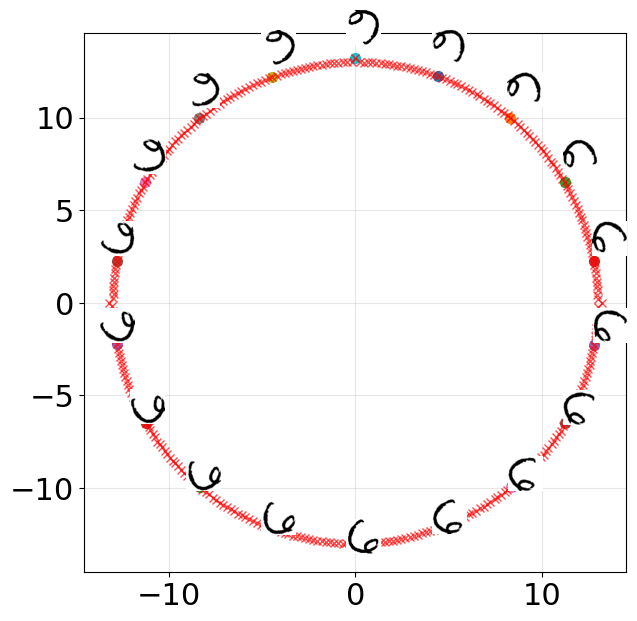

In [16]:
fig, ax = plot_pca_manifold(X, Y, dim_one, 'six_manifold_001.svg')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/six_manifold_001.svg" class="" width="60%" style="vertical-align:middle;">

Figure: <i>The rotated sixes projected onto the first two principal
components. The data lives on a one-dimensional manifold in the
high-dimensional space, forming approximately a circle in the 2D
projection.</i>

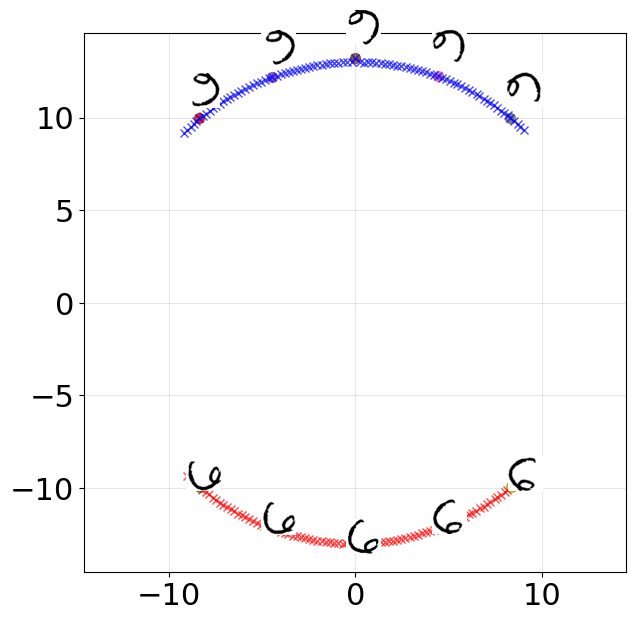

In [17]:
fig, ax = plot_pca_manifold(X, Y, dim_one, 'six_manifold_002.svg',
                                    angle_ranges={'starts': [0, 135, 315], 'ends': [45, 225, 360]},
                                    colors=['r', 'b', 'r'])

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/six_manifold_002.svg" class="" width="60%" style="vertical-align:middle;">

Figure: <i>The rotated sixes projected onto the first two principal
components as sixes and nines. The six and nine data live on two
separate one-dimensional manifolds in the high-dimensional space,
forming two arcs from a circle in the 2D projection.</i>

## Interpoint Distances for Rotated Sixes

In this section we take all 360 examples of the rotated digits and
analyze their interpoint distances. The data set is inherently one
dimensional, with the dimension associated with the rotation
transformation. A pure rotation would lead to a pure circle in the
projected space. In practice, rotation of images requires some
interpolation and this leads to small corruptions of the latent
projections away from the circle.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import mlai
import mlai.plot as plot

In [19]:
# Calculate variance of each dimension
varY = np.var(Y, axis=0)
# Sort by variance in descending order
sorted_indices = np.argsort(varY)[::-1]
# Take top q dimensions (e.g., q=50 for dimensionality reduction)
q = 50
order = sorted_indices[:q]

# Calculate interpoint distances for selected dimensions
Y_selected = Y[:, order]
# Compute squared distances between all pairs
distMat = np.zeros((Y.shape[0], Y.shape[0]))
for i in range(Y.shape[0]):
    for j in range(Y.shape[0]):
        distMat[i, j] = np.sum((Y_selected[i, :] - Y_selected[j, :])**2) / q

# Calculate error term
e = 2 * np.sum(varY[sorted_indices[q:]]) / Y.shape[1]

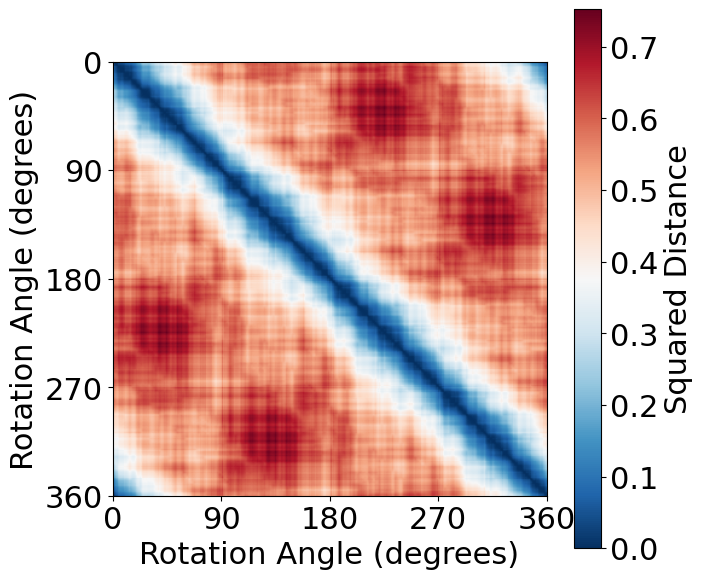

In [20]:
fig, ax = plt.subplots(figsize=plot.big_figsize)

# Create heatmap of interpoint distances
im = ax.imshow(distMat, cmap='RdBu_r', aspect='equal', origin='upper', 
               extent=[0, 360, 360, 0])  # extent: [left, right, bottom, top]
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_yticks([0, 90, 180, 270, 360])
ax.set_xlabel('Rotation Angle (degrees)')
ax.set_ylabel('Rotation Angle (degrees)')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Squared Distance')

mlai.write_figure('dem-six-distances-360.svg', directory='./dimred/')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/dem-six-distances-360.svg" class="" width="60%" style="vertical-align:middle;">

Figure: <i>Inter-point squared distances for the rotated digits data.
Much of the data structure can be seen in the matrix. All points are
ordered by angle of rotation. We can see that the distance between two
points with similar angle of rotation is small (note in the upper right
and lower left corners the low distances associated with 6s rotated by
roughly 360 degrees and unrotated 6s).</i>

In [21]:
import mlai.plot

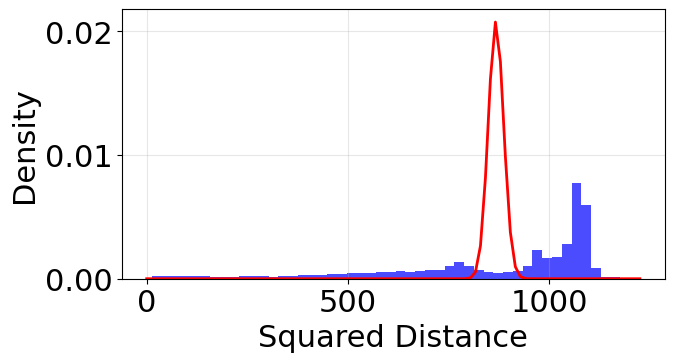

In [22]:
plot.squared_distances(Y, 'rotated-sixes', 'Rotated sixes', directory='./dimred')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/rotated-sixes_squared-distances.svg" class="" width="60%" style="vertical-align:middle;">

Figure: <i>Hisgogram of squared distances vs theory for the rotated
sixes.</i>

## Low Dimensional Manifolds

Of course, in practice pure rotation of the image is too simple a model.
Digits can undergo several distortions and retain their nature. For
example, they can be scaled, they can go through translation, they can
udnergo ‘thinning.’ But, for data with ‘structure’ we expect fewer of
these distortions than the dimension of the data. This means we expect
data to live on a lower dimensonal manifold. This implies that we should
deal with high dimensional data by looking for a lower dimensional
(non-linear) embedding.

# Latent Variables

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/latent-variables.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/latent-variables.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Latent means hidden, and hidden variables are simply *unobservable*
variables. The idea of a latent variable is crucial to the concept of
artificial intelligence, machine learning and experimental design. A
latent variable could take many forms. We might observe a man walking
along a road with a large bag of clothes and we might *infer* that the
man is walking to the laundrette. Our observations are a highly complex
data space, the response in our eyes is processed through our visual
cortex, the combination of the individual’s limb movememnts and the
direction they are walking in all conflate in our heads to cause us to
infer that (perhaps) the individual is going to the laundrette. We don’t
*know* that the man is walking to the laundrette, but we have a model of
the world that suggests that it’s a likely outcome for the very complex
data. In some ways the latent variable can be seen as a *compression* of
this very complex scene. If I were writing a book, I might write that “A
man tripped over whilst walking to the laundrette.” In the reader’s mind
an image of a man, perhaps laden with dirty clothes, may occur. All
these ideas come from our expectations of the world around us. We can
make further inference about the man, some of it perhaps plausible
others less so. The man may be going to the laundrette because his
washing machine is broken, or because he doesn’t have a large enough
flat to have a washing machine, or because he’s carrying a duvet, or
because he doesn’t like ironing. All of these may *increase* in
probability given our observation, but they are still *latent*
variables. Unless we follow the man back to his appartment, or start
making other enquirires about the man, we don’t know the true answer.

It’s clear that to do inference about any complex system we *must*
include latent variables. Latent variables are extremely powerful. In
robotics, they are used to represent the *state* of the robot. The state
of the robot may include its position (in x, y coordinates) its speed,
its direction of facing. How are *these* variables unknown to the robot?
Well the robot only posesses *sensors*, it can make observations of the
nearest object in a certain direction, and it may have a map of its
environment. If we represent the state of the robot as its position on a
map, it may be uncertain of that position. If you go walking or running
in the hills around Sheffield, you can take a very high quality ordnance
survey map with you. However, unless you are a really excellent
orienteer, when you are far from any given landmark, you will probably
be *uncertain* about your true position on the map. These states are
also latent variables.

In statistical analysis of experiments you try to control for each
aspect of the experiment, in particular by *randomisation*. So if I’m
interested in the ability of a particular fertiliser to improve the
yield of a particular plant I may design an experiment where I apply the
fertilizer to some plants (the treatment group) and withold the
fertilizer from others (the control group). I then test to see whether
the yield from the treatment group is better (or worse) than the control
group. I may find that I have an excellent yield for the treatment
group. However, what if I’d (unknowlingly) planted all my treatment
plants in a sunny part of the field, and all the control plants in a
shady part of the field. That would also be a latent variable, in this
case known as a *confounder*. In statistical experimental design
*randomisation* is used to attempt to eliminate the correlated effects
of these confounders: you aim to ensure that if these confounders *do*
exist their effects are not correlated with treatment and contorl. This
is known as a [randomised control
trial](http://en.wikipedia.org/wiki/Randomized_controlled_trial).

Greek philosophers worried a great deal about what was knowable and what
was unknowable. Adherents of [philosophical
Skeptisism](http://en.wikipedia.org/wiki/Skepticism) were inspired by
the idea that since your senses sometimes give you contradictory
information, they cannot be trusted, and in extreme cases they chose to
*ignore* their senses. This is an acknowledgement that very often the
true state of the world cannot be known with precision. Unfortunately,
these philosophers didn’t have a good understanding of probability, so
they were unable to encapsulate their ideas through a *degree* of
belief.

We often use language to express the compression of a complex behavior
or patterns in a simpler way, for example we talk about motives as a
useful distallation for a perhaps very complex patter of behavior. In
physics we use principles of causation and simple laws to describe the
world around us. Such motives or underlying principles are difficult to
observe directly, our conclusions about them emerge over a period of
time by observing indirect consequences of the latent variables.

Epistemic uncertainty allows us to deal with these worries by
associating our degree of belief about the state of the world with a
probaiblity distribution. This core idea underpins state space
modelling, probabilistic graphical models and the wider field of latent
variable modelling. In this session we are going to explore the idea in
a simple linear system and see how it relates to *factor analysis* and
*principal component analysis*.

## Your Personality

At the beginning of the 20th century there was a great deal of interest
amoungst psychologists in formalizing patterns of thought. The approach
they used became known as factor analysis. The principle is that we
observe a potentially high dimensional vector of characteristics about
an individual. To formalize this, social scientists designed
questionaires. We can envisage many questions that we may ask, but the
assumption is that underlying these questions there are only a few
traits that dictate the behavior. These models are known as latent trait
models and the analysis is sometimes known as factor analysis. The idea
is that there are a few characteristic traits that we are looking to
discern. These traits or factors can be extracted by assimilating the
high dimensional characteristics of the individual into a few latent
factors.

## Factor Analysis Model

This causes us to consider a model as follows, if we are given a high
dimensional vector of features (perhaps questionaire answers) associated
with an individual, $\mathbf{ y}$, we assume that these factors are
actually generated from a low dimensional vector latent traits, or
latent variables, which determine the personality. $$
\mathbf{ y}= \mathbf{f}(\mathbf{ z}) + \boldsymbol{ \epsilon},
$$ where $\mathbf{f}(\mathbf{ z})$ is a *vector valued* function that is
dependent on the latent traits and $\boldsymbol{ \epsilon}$ is some
corrupting noise. For simplicity, we assume that the function is given
by a *linear* relationship, $$
\mathbf{f}(\mathbf{ z}) = \mathbf{W}\mathbf{ z}
$$ where we have introduced a matrix $\mathbf{W}$ that is sometimes
referred to as the *factor loadings* but we also immediately see is
related to our *multivariate linear regression* models from the . That
is because our vector valued function is of the form

$$
\mathbf{f}(\mathbf{ z}) =
\begin{bmatrix} f_1(\mathbf{ z}) \\ f_2(\mathbf{ z}) \\ \vdots \\
f_p(\mathbf{ z})\end{bmatrix}
$$ where there are $d$ features associated with the individual. If we
consider any of these functions individually we have a prediction
function that looks like a regression model, $$
f_j(\mathbf{ z}) =
\mathbf{ w}_{j, :}^\top \mathbf{ z},
$$ for each element of the vector valued function, where
$\mathbf{ w}_{:, j}$ is the $j$th column of the matrix $\mathbf{W}$. In
that context each column of $\mathbf{W}$ is a vector of *regression
weights*. This is a multiple input and multiple output regression. Our
inputs (or covariates) have dimensionality greater than 1 and our
outputs (or response variables) also have dimensionality greater than
one. Just as in a standard regression, we are assuming that we don’t
observe the function directly (note that this *also* makes the function
a *type* of latent variable), but we observe some corrupted variant of
the function, where the corruption is given by $\boldsymbol{ \epsilon}$.
Just as in linear regression we can assume that this corruption is given
by Gaussian noise, where the noise for the $j$th element of
$\mathbf{ y}$ is by, $$
\epsilon_j \sim \mathscr{N}\left(0,\sigma^2_j\right).
$$ Of course, just as in a regression problem we also need to make an
assumption across the individual data points to form our full
likelihood. Our data set now consists of many observations of
$\mathbf{ y}$ for diffetent individuals. We store these observations in
a *design matrix*, $\mathbf{Y}$, where each *row* of $\mathbf{Y}$
contains the observation for one individual. To emphasize that
$\mathbf{ y}$ is a vector derived from a row of $\mathbf{Y}$ we
represent the observation of the features associated with the $i$th
individual by $\mathbf{ y}_{i, :}$, and place each individual in our
data matrix, $$
\mathbf{Y}
= \begin{bmatrix} \mathbf{ y}_{1, :}^\top \\ \mathbf{ y}_{2, :}^\top \\ \vdots \\
\mathbf{ y}_{n, :}^\top\end{bmatrix},
$$ where we have $n$ data points. Our data matrix therefore has $n$ rows
and $p$ columns. The point to notice here is that each data obsesrvation
appears as a row vector in the design matrix (thus the transpose
operation inside the brackets). Our prediction functions are now
actually a *matrix value* function, $$
\mathbf{F} = \mathbf{Z}\mathbf{W}^\top,
$$ where for each matrix the data points are in the rows and the data
features are in the columns. This implies that if we have $q$ inputs to
the function we have $\mathbf{F}\in \Re^{n\times p}$,
$\mathbf{W}\in \Re^{p \times q}$ and $\mathbf{Z}\in \Re^{n\times q}$.

### Exercise 1

Show that, given all the definitions above, if, $$
\mathbf{F} = \mathbf{Z}\mathbf{W}^\top
$$ and the elements of the vector valued function $\mathbf{F}$ are given
by $$
f_{i, j} = f_j(\mathbf{ z}_{i, :}),
$$ where $\mathbf{ z}_{i, :}$ is the $i$th row of the latent variables,
$\mathbf{Z}$, then show that $$
f_j(\mathbf{ z}_{i, :}) = \mathbf{ w}_{j, :}^\top
\mathbf{ z}_{i, :}
$$

### Exercise 1 Answer

Write your answer to Exercise 1 here

## Latent Variables vs Linear Regression

The difference between this model and a multiple output regression is
that in the regression case we are provided with the covariates
$\mathbf{Z}$, here they are *latent variables*. These variables are
unknown. Just as we have done in the past for unknowns, we now treat
them with a probability distribution. In *factor analysis* we assume
that the latent variables have a Gaussian density which is independent
across both across the latent variables associated with the different
data points, and across those associated with different data features,
so we have, $$
x_{i,j} \sim
\mathscr{N}\left(0,1\right),
$$ and we can write the density governing the latent variable associated
with a single point as, $$
\mathbf{ z}_{i, :} \sim \mathscr{N}\left(\mathbf{0},\mathbf{I}\right).
$$ If we consider the values of the function for the $i$th data point as
$$
\mathbf{f}_{i, :} =
\mathbf{f}(\mathbf{ z}_{i, :}) = \mathbf{W}\mathbf{ z}_{i, :} 
$$ then we can use the rules for multivariate Gaussian relationships to
write that $$
\mathbf{f}_{i, :} \sim \mathscr{N}\left(\mathbf{0},\mathbf{W}\mathbf{W}^\top\right)
$$ which implies that the distribution for $\mathbf{ y}_{i, :}$ is given
by $$
\mathbf{ y}_{i, :} = \sim \mathscr{N}\left(\mathbf{0},\mathbf{W}\mathbf{W}^\top + \boldsymbol{\Sigma}\right)
$$ where $\boldsymbol{\Sigma}$ the covariance of the noise variable,
$\epsilon_{i, :}$ which for factor analysis is a diagonal matrix
(because we have assumed that the noise was *independent* across the
features), $$
\boldsymbol{\Sigma} = \begin{bmatrix}\sigma^2_{1} & 0 & 0 & 0\\
0 & \sigma^2_{2} & 0 & 0\\
                                     0 & 0 & \ddots &
0\\
                                     0 & 0 & 0 & \sigma^2_p\end{bmatrix}.
$$ For completeness, we could also add in a *mean* for the data vector
$\boldsymbol{ \mu}$, $$
\mathbf{ y}_{i, :} = \mathbf{W}\mathbf{ z}_{i, :} +
\boldsymbol{ \mu}+ \boldsymbol{ \epsilon}_{i, :}
$$ which would give our marginal distribution for $\mathbf{ y}_{i, :}$ a
mean $\boldsymbol{ \mu}$. However, the maximum likelihood solution for
$\boldsymbol{ \mu}$ turns out to equal the empirical mean of the data,
$$
\boldsymbol{ \mu}= \frac{1}{n} \sum_{i=1}^n
\mathbf{ y}_{i, :},
$$ *regardless* of the form of the covariance,
$\mathbf{C}= \mathbf{W}\mathbf{W}^\top + \boldsymbol{\Sigma}$. As a
result it is very common to simply preprocess the data and ensure it is
zero mean. We will follow that convention for this session.

The prior density over latent variables is independent, and the
likelihood is independent, that means that the marginal likelihood here
is also independent over the data points. Factor analysis was developed
mainly in psychology and the social sciences for understanding
personality and intelligence. [Charles
Spearman](http://en.wikipedia.org/wiki/Charles_Spearman) was concerned
with the measurements of “the abilities of man” and is credited with the
earliest version of factor analysis.

# Principal Component Analysis

In 1933 [Harold
Hotelling](http://en.wikipedia.org/wiki/Harold_Hotelling) published on
*principal component analysis* the first mention of this approach
(Hotelling, 1933). Hotelling’s inspiration was to provide mathematical
foundation for factor analysis methods that were by then widely used
within psychology and the social sciences. His model was a factor
analysis model, but he considered the noiseless ‘limit’ of the model. In
other words he took $\sigma^2_i \rightarrow 0$ so that he had

$$
\mathbf{ y}_{i, :} \sim \lim_{\sigma^2 \rightarrow 0} \mathscr{N}\left(\mathbf{0},\mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}\right).
$$ The paper had two unfortunate effects. Firstly, the resulting model
is no longer valid probablistically, because the covariance of this
Gaussian is ‘degenerate.’ Because $\mathbf{W}\mathbf{W}^\top$ has rank
of at most $q$ where $q<p$ (due to the dimensionality reduction) the
determinant of the covariance is zero, meaning the inverse doesn’t exist
so the density, $$
p(\mathbf{ y}_{i, :}|\mathbf{W}) =
\lim_{\sigma^2 \rightarrow 0} \frac{1}{(2\pi)^\frac{p}{2}
|\mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}|^{\frac{1}{2}}}
\exp\left(-\frac{1}{2}\mathbf{ y}_{i, :}\left[\mathbf{W}\mathbf{W}^\top+ \sigma^2
\mathbf{I}\right]^{-1}\mathbf{ y}_{i, :}\right),
$$ is *not* valid for $q<p$ (where $\mathbf{W}\in \Re^{p\times q}$).
This mathematical consequence is a probability density which has no
‘support’ in large regions of the space for $\mathbf{ y}_{i, :}$. There
are regions for which the probability of $\mathbf{ y}_{i, :}$ is zero.
These are any regions that lie off the hyperplane defined by mapping
from $\mathbf{ z}$ to $\mathbf{ y}$ with the matrix $\mathbf{W}$. In
factor analysis the noise corruption, $\boldsymbol{ \epsilon}$, allows
for points to be found away from the hyperplane. In Hotelling’s PCA the
noise variance is zero, so there is only support for points that fall
precisely on the hyperplane. Secondly, Hotelling explicity chose to
rename factor analysis as principal component analysis, arguing that the
factors social scientist sought were different in nature to the concept
of a mathematical factor. This was unfortunate because the factor
loadings, $\mathbf{W}$ can also be seen as factors in the mathematical
sense because the model Hotelling defined is a Gaussian model with
covariance given by $\mathbf{C}= \mathbf{W}\mathbf{W}^\top$ so
$\mathbf{W}$ is a *factor* of the covariance in the mathematical sense,
as well as a factor loading.

However, the paper had one great advantage over standard approaches to
factor analysis. Despite the fact that the model was a special case that
is subsumed by the more general approach of factor analysis it is this
special case that leads to a particular algorithm, namely that the
factor loadings (or principal components as Hotelling referred to them)
are given by an *eigenvalue decomposition* of the empirical covariance
matrix.

## Computation of the Marginal Likelihood

$$
\mathbf{ y}_{i,:}=\mathbf{W}\mathbf{ z}_{i,:}+\boldsymbol{ \epsilon}_{i,:},\quad \mathbf{ z}_{i,:} \sim \mathscr{N}\left(\mathbf{0},\mathbf{I}\right), \quad \boldsymbol{ \epsilon}_{i,:} \sim \mathscr{N}\left(\mathbf{0},\sigma^{2}\mathbf{I}\right)
$$

$$
\mathbf{W}\mathbf{ z}_{i,:} \sim \mathscr{N}\left(\mathbf{0},\mathbf{W}\mathbf{W}^\top\right)
$$

$$
\mathbf{W}\mathbf{ z}_{i, :} + \boldsymbol{ \epsilon}_{i, :} \sim \mathscr{N}\left(\mathbf{0},\mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}\right)
$$

*Probabilistic PCA Max. Likelihood Soln* (Tipping and Bishop (1999a))

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/ppca_graphical.svg" class="" width="40%" style="vertical-align:middle;">

Figure: <i>Graphical model representing probabilistic PCA.</i>

$$p\left(\mathbf{Y}|\mathbf{W}\right)=\prod_{i=1}^{n}\mathscr{N}\left(\mathbf{ y}_{i, :}|\mathbf{0},\mathbf{W}\mathbf{W}^{\top}+\sigma^{2}\mathbf{I}\right)$$

## Eigenvalue Decomposition

Eigenvalue problems are widespreads in physics and mathematics, they are
often written as a matrix/vector equation but we prefer to write them as
a full matrix equation. In an eigenvalue problem you are looking to find
a matrix of eigenvectors, $\mathbf{U}$ and a *diagonal* matrix of
eigenvalues, $\boldsymbol{\Lambda}$ that satisfy the *matrix* equation
$$
\mathbf{A}\mathbf{U} = \mathbf{U}\boldsymbol{\Lambda}.
$$ where $\mathbf{A}$ is your matrix of interest. This equation is not
trivially solvable through matrix inverse because matrix multiplication
is not [commutative](http://en.wikipedia.org/wiki/Commutative_property),
so premultiplying by $\mathbf{U}^{-1}$ gives $$
\mathbf{U}^{-1}\mathbf{A}\mathbf{U}
= \boldsymbol{\Lambda}, 
$$ where we remember that $\boldsymbol{\Lambda}$ is a *diagonal* matrix,
so the eigenvectors can be used to *diagonalise* the matrix. When
performing the eigendecomposition on a Gaussian covariances,
diagonalisation is very important because it returns the covariance to a
form where there is no correlation between points.

## Positive Definite

We are interested in the case where $\mathbf{A}$ is a covariance matrix,
which implies it is *positive definite*. A positive definite matrix is
one for which the inner product, $$
\mathbf{ w}^\top \mathbf{C}\mathbf{ w}
$$ is positive for *all* values of the vector $\mathbf{ w}$ other than
the zero vector. One way of creating a positive definite matrix is to
assume that the symmetric and positive definite matrix
$\mathbf{C}\in \Re^{p\times p}$ is factorised into,
$\mathbf{A}in \Re^{p\times p}$, a *full rank* matrix, so that $$
\mathbf{C}= \mathbf{A}^\top
\mathbf{A}.
$$ This ensures that $\mathbf{C}$ must be positive definite because $$
\mathbf{ w}^\top \mathbf{C}\mathbf{ w}=\mathbf{ w}^\top
\mathbf{A}^\top\mathbf{A}\mathbf{ w}
$$ and if we now define a new *vector* $\mathbf{b}$ as $$
\mathbf{b} = \mathbf{A}\mathbf{ w}
$$ we can now rewrite as $$
\mathbf{ w}^\top \mathbf{C}\mathbf{ w}= \mathbf{b}^\top\mathbf{b} = \sum_{i}
b_i^2
$$ which, since it is a sum of squares, is positive or zero. The
constraint that $\mathbf{A}$ must be *full rank* ensures that there is
no vector $\mathbf{ w}$, other than the zero vector, which causes the
vector $\mathbf{b}$ to be all zeros.

### Exercise 2

If $\mathbf{C}=\mathbf{A}^\top \mathbf{A}$ then express $c_{i,j}$, the
value of the element at the $i$th row and the $j$th column of
$\mathbf{C}$, in terms of the columns of $\mathbf{A}$. Use this to show
that (i) the matrix is symmetric and (ii) the matrix has positive
elements along its diagonal.

### Exercise 2 Answer

Write your answer to Exercise 2 here

## Eigenvectors of a Symmetric Matric

Symmetric matrices have *orthonormal* eigenvectors. This means that
$\mathbf{U}$ is an [orthogonal
matrix](http://en.wikipedia.org/wiki/Orthogonal_matrix),
$\mathbf{U}^\top\mathbf{U} = \mathbf{I}$. This implies that
$\mathbf{u}_{:, i} ^\top \mathbf{u}_{:, j}$ is equal to 0 if $i\neq j$
and 1 if $i=j$.

## Probabilistic PCA

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/probabilistic-pca.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/probabilistic-pca.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

This linear relationship between the observed data and the latent
variables is at the heart of Hotelling’s original formulation of PCA. It
explicitly models the idea that the observed high-dimensional data is
generated from a lower-dimensional set of latent variables, with some
added noise. This perspective aligns PCA more closely with factor
analysis and highlights its nature as a latent variable model.

Probabilistic PCA (PPCA) provides a probabilistic interpretation of PCA
by explicitly modeling the generative process that creates the observed
data. The model assumes that each high-dimensional data point
$\mathbf{ y}_{i,:}$ is generated from a lower-dimensional latent
variable $\mathbf{ z}_{i,:}$ through a linear transformation with added
Gaussian noise: $$
\mathbf{ y}_{i,:} = \mathbf{W}\mathbf{ z}_{i,:} + \boldsymbol{ \epsilon}_{i,:}
$$ where
$\boldsymbol{ \epsilon}_{i,:} \sim \mathscr{N}\left(\mathbf{0},\sigma^2\mathbf{I}\right)$
represents isotropic Gaussian noise. The model places a standard
Gaussian prior over the latent variables: $$
p(\mathbf{ z}_{i,:}) = \mathscr{N}\left(\mathbf{ z}_{i,:}|\mathbf{0},\mathbf{I}\right)
$$ Given these assumptions, the conditional probability of observing a
data point given its latent representation is: $$
p(\mathbf{ y}_{i,:}|\mathbf{ z}_{i,:},\mathbf{W}) = \mathscr{N}\left(\mathbf{ y}_{i,:}|\mathbf{W}\mathbf{ z}_{i,:},\sigma^2\mathbf{I}\right)
$$ By integrating out the latent variables, we obtain the marginal
likelihood of the data: $$
p(\mathbf{ y}_{i,:}|\mathbf{W}) = \mathscr{N}\left(\mathbf{ y}_{i,:}|\mathbf{0},\mathbf{W}\mathbf{W}^{\top}+\sigma^{2}\mathbf{I}\right)
$$ This probabilistic formulation, developed by Tipping and Bishop
(Tipping and Bishop, 1999a), provides a principled framework that not
only recovers classical PCA as a special case when $\sigma^2 \to 0$, but
also enables extensions like handling missing data and mixture models.

In [23]:
from mlai import plot
import mlai
from matplotlib import pyplot as plt

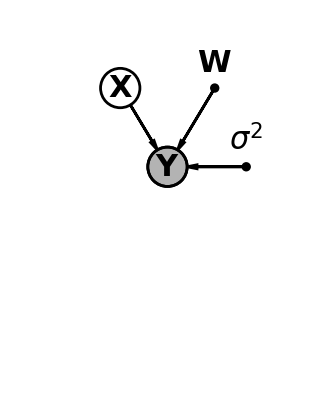

In [24]:
pgm = plot.ppca_graphical_model()
filename = mlai.filename_join('ppca_graphical_model.svg', directory='./dimred')
pgm.render().figure.savefig(filename, transparent=True)

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/ppca_graphical_model.svg" class="" width="60%" style="vertical-align:middle;">

Figure: <i>Graphical model representing probabilistic PCA.</i>

## Probabilistic PCA

In 1997 [Tipping and
Bishop](http://research.microsoft.com/pubs/67218/bishop-ppca-jrss.pdf)
(Tipping and Bishop, 1999b) and
[Roweis](https://www.cs.nyu.edu/~roweis/papers/empca.pdf) (Roweis, n.d.)
independently revisited Hotelling’s model and considered the case where
the noise variance was finite, but *shared* across all output dimensons.
Their model can be thought of as a factor analysis where $$
\boldsymbol{\Sigma} = \sigma^2 \mathbf{I}.
$$ This leads to a marginal likelihood of the form $$
p(\mathbf{Y}|\mathbf{W}, \sigma^2)
= \prod_{i=1}^n\mathscr{N}\left(\mathbf{ y}_{i, :}|\mathbf{0},\mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}\right)
$$ where the limit of $\sigma^2\rightarrow 0$ is *not* taken. This
defines a proper probabilistic model. Tippping and Bishop then went on
to prove that the *maximum likelihood* solution of this model with
respect to $\mathbf{W}$ is given by an eigenvalue problem. In the
probabilistic PCA case the eigenvalues and eigenvectors are given as
follows. $$
\mathbf{W}= \mathbf{U}\mathbf{L} \mathbf{R}^\top
$$ where $\mathbf{U}$ is the eigenvectors of the empirical covariance
matrix $$
\mathbf{S}= \sum_{i=1}^n(\mathbf{ y}_{i, :} - \boldsymbol{ \mu})(\mathbf{ y}_{i,:} - \boldsymbol{ \mu})^\top,
$$ which can be written
$\mathbf{S}= \frac{1}{n} \mathbf{Y}^\top\mathbf{Y}$ if the data is zero
mean. The matrix $\mathbf{L}$ is diagonal and is dependent on the
*eigenvalues* of $\mathbf{S}$, $\boldsymbol{\Lambda}$. If the $i$th
diagonal element of this matrix is given by $\lambda_i$ then the
corresponding element of $\mathbf{L}$ is $$
\ell_i = \sqrt{\lambda_i - \sigma^2}
$$ where $\sigma^2$ is the noise variance. Note that if $\sigma^2$ is
larger than any particular eigenvalue, then that eigenvalue (along with
its corresponding eigenvector) is *discarded* from the solution.

## PPCA as Manifold Learning

Probabilistic PCA can be viewed as a simple manifold learning algorithm.
It assumes that:

1.  The data lies near a linear manifold (subspace) of the
    high-dimensional space
2.  The deviation from this manifold is Gaussian noise
3.  The intrinsic dimensionality is specified by the number of retained
    components

This view helps explain why PPCA works well when the manifold hypothesis
holds and the manifold is approximately linear. When the manifold is
nonlinear, we need more sophisticated methods like kernel PCA or neural
network-based approaches.

## Python Implementation of Probabilistic PCA

We will now implement this algorithm in python.

In [25]:
import numpy as np

In [26]:
from mlai import ppca_eig
import inspect
file_path = inspect.getfile(ppca_eig)

In [27]:
# %load -s ppca_eig /Users/neil/lawrennd/mlai/mlai/mlai.py
def ppca_eig(Y, q):
    """Perform probabilistic principle component analysis"""
    
    Y_cent = Y - Y.mean(0)

    # Comute covariance
    S = np.dot(Y_cent.T, Y_cent)/Y.shape[0]
    lambd, U = np.linalg.eig(S)

    # Choose number of eigenvectors
    sigma2 = np.sum(lambd[q:])/(Y.shape[1]-q)
    l = np.sqrt(lambd[:q]-sigma2)
    W = U[:, :q]*l[None, :]
    return W, sigma2


In [28]:
ppca = ppca_eig

In practice we may not wish to compute the eigenvectors of the
covariance matrix directly. This is because it requires us to estimate
the covariance, which involves a sum of squares term, before estimating
the eigenvectors. We can estimate the eigenvectors directly either
through [QR
decomposition](http://en.wikipedia.org/wiki/QR_decomposition) or
[singular value
decomposition](http://en.wikipedia.org/wiki/Singular_value_decomposition).
We saw a similar issue arise when , where we also wished to avoid
computation of $\mathbf{Z}^\top\mathbf{Z}$ (or in the case of
$\boldsymbol{\Phi}^\top\boldsymbol{\Phi}$).

## Posterior for Principal Component Analysis

Under the latent variable model justification for principal component
analysis, we are normally interested in inferring something about the
latent variables given the data. This is the distribution, $$
p(\mathbf{ z}_{i, :} | \mathbf{ y}_{i, :})
$$ for any given data point. Determining this density turns out to be
very similar to the approach for determining the Bayesian posterior of
$\mathbf{ w}$ in Bayesian linear regression, only this time we place the
prior density over $\mathbf{ z}_{i, :}$ instead of $\mathbf{ w}$. The
posterior is proportional to the joint density as follows, $$
p(\mathbf{ z}_{i, :} | \mathbf{ y}_{i, :}) \propto p(\mathbf{ y}_{i,
:}|\mathbf{W}, \mathbf{ z}_{i, :}, \sigma^2) p(\mathbf{ z}_{i, :})
$$ And as in the Bayesian linear regression case we first consider the
log posterior, $$
\log p(\mathbf{ z}_{i, :} | \mathbf{ y}_{i, :}) = \log p(\mathbf{ y}_{i, :}|\mathbf{W},
\mathbf{ z}_{i, :}, \sigma^2) + \log p(\mathbf{ z}_{i, :}) + \text{const}
$$ where the constant is not dependent on $\mathbf{ z}$. As before we
collect the quadratic terms in $\mathbf{ z}_{i, :}$ and we assemble them
into a Gaussian density over $\mathbf{ z}$. $$
\log p(\mathbf{ z}_{i, :} | \mathbf{ y}_{i, :}) =
-\frac{1}{2\sigma^2} (\mathbf{ y}_{i, :} - \mathbf{W}\mathbf{ z}_{i,
:})^\top(\mathbf{ y}_{i, :} - \mathbf{W}\mathbf{ z}_{i, :}) - \frac{1}{2}
\mathbf{ z}_{i, :}^\top \mathbf{ z}_{i, :} + \text{const}
$$

### Exercise 3

Multiply out the terms in the brackets. Then collect the quadratic term
and the linear terms together. Show that the posterior has the form $$
\mathbf{ z}_{i, :} | \mathbf{W}\sim \mathscr{N}\left(\boldsymbol{ \mu}_x,\mathbf{C}_x\right)
$$ where $$
\mathbf{C}_x = \left(\sigma^{-2}
\mathbf{W}^\top\mathbf{W}+ \mathbf{I}\right)^{-1}
$$ and $$
\boldsymbol{ \mu}_x
= \mathbf{C}_x \sigma^{-2}\mathbf{W}^\top \mathbf{ y}_{i, :} 
$$ Compare this to the posterior for the Bayesian linear regression from
last week, do they have similar forms? What matches and what differs?

### Exercise 3 Answer

Write your answer to Exercise 3 here

## Python Implementation of the Posterior

Now let’s implement the system in code.

### Exercise 4

Use the values for $\mathbf{W}$ and $\sigma^2$ you have computed, along
with the data set $\mathbf{Y}$ to compute the posterior density over
$\mathbf{Z}$. Write a function of the form

``` python
mu_x, C_x = posterior(Y, W, sigma2)
```

where `mu_x` and `C_x` are the posterior mean and posterior covariance
for the given $\mathbf{Y}$.

Don’t forget to subtract the mean of the data `Y` inside your function
before computing the posterior: remember we assumed at the beginning of
our analysis that the data had been centred (i.e. the mean was removed).

In [29]:
# Write your answer to Exercise 4 here


# Answer Code
# Write code for you answer to this exercise in this box
# Do not delete these comments, otherwise you will get zero for this answer.
# Make sure your code has run and the answer is correct *before* submitting your notebook for marking.
import numpy as np
import scipy as sp
def posterior(Y, W, sigma2):
    Y_cent = Y - Y.mean(0)
    # Compute posterior over X
    C_x = 
    mu_x = 
    return mu_x, C_x



SyntaxError: invalid syntax (2985527837.py, line 13)

## Numerically Stable and Efficient Version

Just as we saw for and computation of a matrix such as
$\mathbf{Y}^\top\mathbf{Y}$ (or its centred version) can be a bad idea
in terms of loss of numerical accuracy. Fortunately, we can find the
eigenvalues and eigenvectors of the matrix $\mathbf{Y}^\top\mathbf{Y}$
without direct computation of the matrix. This can be done with the
[*singular value
decomposition*](http://en.wikipedia.org/wiki/Singular_value_decomposition).
The singular value decompsition takes a matrix, $\mathbf{Z}$ and
represents it in the form, $$
\mathbf{Z} = \mathbf{U}\boldsymbol{\Lambda}\mathbf{V}^\top
$$ where $\mathbf{U}$ is a matrix of orthogonal vectors in the columns,
meaning $\mathbf{U}^\top\mathbf{U} = \mathbf{I}$. It has the same number
of rows and columns as $\mathbf{Z}$. The matrices $\mathbf{\Lambda}$ and
$\mathbf{V}$ are both square with dimensionality given by the number of
columns of $\mathbf{Z}$. The matrix $\mathbf{\Lambda}$ is *diagonal* and
$\mathbf{V}$ is an orthogonal matrix so
$\mathbf{V}^\top\mathbf{V} = \mathbf{V}\mathbf{V}^\top = \mathbf{I}$.
The eigenvalues of the matrix $\mathbf{Y}^\top\mathbf{Y}$ are then given
by the singular values of the matrix $\mathbf{Y}^\top$ squared and the
eigenvectors are given by $\mathbf{U}$.

## Solution for $\mathbf{W}$

Given the singular value decomposition of $\mathbf{Y}$ then we have $$
\mathbf{W}=
\mathbf{U}\mathbf{L}\mathbf{R}^\top
$$ where $\mathbf{R}$ is an arbitrary rotation matrix. This implies that
the posterior is given by $$
\mathbf{C}_x =
\left[\sigma^{-2}\mathbf{R}\mathbf{L}^2\mathbf{R}^\top + \mathbf{I}\right]^{-1}
$$ because $\mathbf{U}^\top \mathbf{U} = \mathbf{I}$. Since, by
convention, we normally take $\mathbf{R} = \mathbf{I}$ to ensure that
the principal components are orthonormal we can write $$
\mathbf{C}_x = \left[\sigma^{-2}\mathbf{L}^2 +
\mathbf{I}\right]^{-1}
$$ which implies that $\mathbf{C}_x$ is actually diagonal with elements
given by $$
c_i = \frac{\sigma^2}{\sigma^2 + \ell^2_i}
$$ and allows us to write $$
\boldsymbol{ \mu}_x = [\mathbf{L}^2 + \sigma^2
\mathbf{I}]^{-1} \mathbf{L} \mathbf{U}^\top \mathbf{ y}_{i, :}
$$ $$
\boldsymbol{ \mu}_x = \mathbf{D}\mathbf{U}^\top \mathbf{ y}_{i, :}
$$ where $\mathbf{D}$ is a diagonal matrix with diagonal elements given
by $d_{i} = \frac{\ell_i}{\sigma^2 + \ell_i^2}$.

In [30]:
import scipy as sp
import numpy as np

In [31]:
from mlai import ppca_svd
import inspect
file_path = inspect.getfile(ppca_svd)

In [32]:
# %load -s ppca_svd /Users/neil/lawrennd/mlai/mlai/mlai.py
def ppca_svd(Y, q, center=True):
    """Probabilistic PCA through singular value decomposition"""
    # remove mean
    if center:
        Y_cent = Y - Y.mean(0)
    else:
        Y_cent = Y
        
    # Comute singluar values, discard 'R' as we will assume orthogonal
    U, sqlambd, _ = sp.linalg.svd(Y_cent.T,full_matrices=False)
    lambd = (sqlambd**2)/Y.shape[0]
    # Compute residual and extract eigenvectors
    sigma2 = np.sum(lambd[q:])/(Y.shape[1]-q)
    ell = np.sqrt(lambd[:q]-sigma2)
    return U[:, :q], ell, sigma2


In [33]:
from mlai import ppca_posterior
import inspect
file_path = inspect.getfile(ppca_posterior)

In [34]:
# %load -s ppca_posterior /Users/neil/lawrennd/mlai/mlai/mlai.py
def ppca_posterior(Y, U, ell, sigma2, center=True):
    """Posterior computation for the latent variables given the eigendecomposition."""
    if center:
        Y_cent = Y - Y.mean(0)
    else:
        Y_cent = Y
    C_x = np.diag(sigma2/(sigma2+ell**2))
    d = ell/(sigma2+ell**2)
    mu_x = np.dot(Y_cent, U)*d[None, :]
    return mu_x, C_x


In [35]:
ppca = ppca_svd
posterior = ppca_posterior

## Scikit-learn implementation PCA

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/oil-flow-sklearn-pca.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/oil-flow-sklearn-pca.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We’ve implemented PCA as part of supporting the learning process, but in
practice we can use the `scikit-learn` implementation. Let’s try it on
the oil flow data.

## Oil Flow Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_datasets/includes/oil-flow-data.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_datasets/includes/oil-flow-data.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

This data set is from a physics-based simulation of oil flow in a
pipeline. The data was generated as part of a project to determine the
fraction of oil, water and gas in North Sea oil pipes (Bishop and James,
1993).

In [36]:
import pods

In [37]:
data = pods.datasets.oil()

The data consists of 1000 12-dimensional observations of simulated oil
flow in a pipeline. Each observation is labelled according to the
multi-phase flow configuration (homogeneous, annular or laminar).

In [38]:
# Convert data["Y"] from [1, -1, -1] in each row to rows of 0 or 1 or 2
Y = data["Y"]
# Find rows with 1 in first column (class 0)
class0 = (Y[:, 0] == 1).astype(int) * 0
# Find rows with 1 in second column (class 1) 
class1 = (Y[:, 1] == 1).astype(int) * 1
# Find rows with 1 in third column (class 2)
class2 = (Y[:, 2] == 1).astype(int) * 2
# Combine into single array of class labels 0,1,2
labels = class0 + class1 + class2

The data is returned as a dictionary containing training and test inputs
(‘X,’ ‘Xtst’), training and test labels (‘Y,’ ‘Ytst’), and the names of
the features.

In [39]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai
import numpy as np

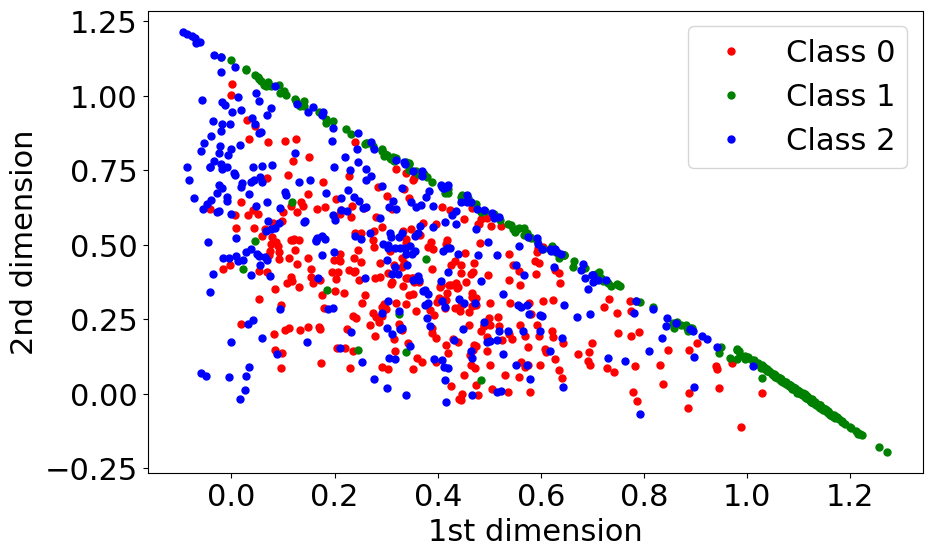

In [40]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
# Plot first two dimensions of the data
classes = np.unique(labels)
colors = ['r', 'g', 'b']
for i, cls in enumerate(classes):
    idx = labels == cls
    ax.plot(data['X'][idx, 0], data['X'][idx, 1], colors[i] + '.', 
            markersize=10, label=f'Class {cls}')
ax.set_xlabel('1st dimension')
ax.set_ylabel('2nd dimension')
ax.legend()

mlai.write_figure('oil-flow-data.svg', directory='./datasets')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//datasets/oil-flow-data.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Visualization of the first two dimensions of the oil flow
data from Bishop and James (1993)</i>

As normal we include the citation information for the data.

In [41]:
print(data['citation'])

Bishop, C. M. and G. D. James (1993). Analysis of multiphase flows using dual-energy gamma densitometry and neural networks. Nuclear Instruments and Methods in Physics Research A327, 580-593


And extra information about the data is included, as standard, under the
keys `info` and `details`.

In [42]:
print(data['details'])

The three phase oil data used initially for demonstrating the Generative Topographic mapping.


In [43]:
X = data['X']
Y = data['Y']

In [44]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [45]:
from sklearn.decomposition import PCA

In [46]:
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

In [47]:
# Find rows with 1 in first column (class 0)
class0 = (Y[:, 0] == 1).astype(int) * 0
# Find rows with 1 in second column (class 1) 
class1 = (Y[:, 1] == 1).astype(int) * 1
# Find rows with 1 in third column (class 2)
class2 = (Y[:, 2] == 1).astype(int) * 2
# Combine into single array of class labels 0,1,2
lbls = class0 + class1 + class2

In [48]:
from matplotlib import pyplot as plt
import mlai
from mlai import plot

In [52]:
ax.legend?

Signature: ax.legend(*args, **kwargs)
Docstring:
Place a legend on the Axes.

Call signatures::

    legend()
    legend(handles, labels)
    legend(handles=handles)
    legend(labels)

The call signatures correspond to the following different ways to use
this method:

**1. Automatic detection of elements to be shown in the legend**

The elements to be added to the legend are automatically determined,
when you do not pass in any extra arguments.

In this case, the labels are taken from the artist. You can specify
them either at artist creation or by calling the
:meth:`~.Artist.set_label` method on the artist::

    ax.plot([1, 2, 3], label='Inline label')
    ax.legend()

or::

    line, = ax.plot([1, 2, 3])
    line.set_label('Label via method')
    ax.legend()

.. note::
    Specific artists can be excluded from the automatic legend element
    selection by using a label starting with an underscore, "_".
    A string starting with an underscore is the default label for all
    artist

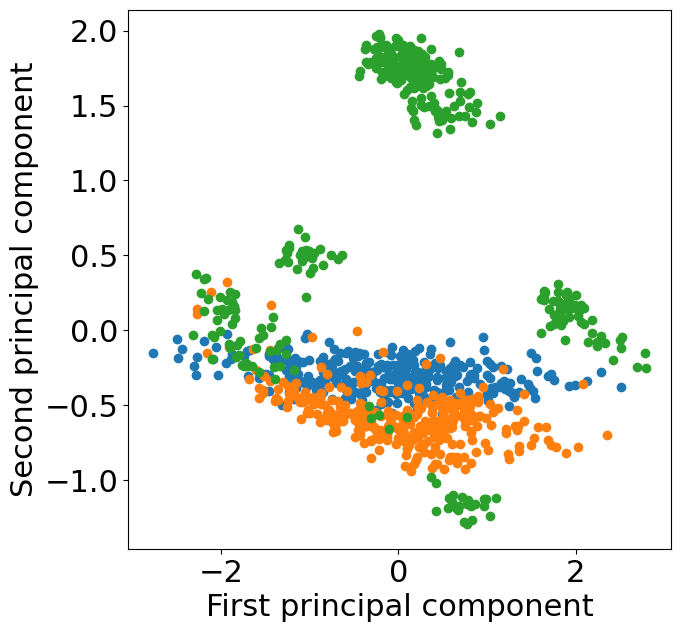

In [55]:
fig, ax = plt.subplots(figsize=plot.big_figsize)
# Three labels stored in Y
labels = ["homogeneous", "annular", "stratified"]
for i in range(3):
    ax.scatter(X_pca[lbls==i, 0], X_pca[lbls==i, 1], label=f'{labels[i]}')
ax.set_xlabel('First principal component')
ax.set_ylabel('Second principal component')


mlai.write_figure("oil-flow-pca-sklearn.svg", directory='./dimred')

Figure: <i>PCA of the oil flow data.</i>

## The Probabilistic PCA Model

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/probabilistic-pca-model.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/probabilistic-pca-model.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

For our notation, we express the $i$th data point’s position in the
underlying latent space by the vector $\mathbf{ z}_{i, :}$. The
relationship between the latent space and the data space in the form of
a linear mapping, \[ *{i, :} = *{i, :} + + *{i, :} \] where
$\mathbf{W}\in \Re^{d,q}$ is a mapping matrix which encodes the
relationship between the latent space and the data space. The vector
$\boldsymbol{ \epsilon}$ represents the corrupting noise. We will assume
the noise is independently sampled from a Gaussian density, \[ *{i,:} ,
\] where $\sigma$ is the standard deviation of the corrupting noise.

Linear dimensionality reduction can be thought of as finding a lower
dimensional plane embedded in a higher dimensional space. The plane is
described by the matrix $\mathbf{W}$. The direction of the vectors in
this matrix define the orientation of the plane. The figure below shows
how this works when the latent space is two dimensional and the data
space is three dimensional.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import mlai
import mlai.plot as plot

In [ ]:
fig = plt.figure(figsize=(15, 5))

# Parameters
alpha = 1
number_across = 10
num_samples = 3

# Create 2D grid in latent space
x1 = np.linspace(-1, 1, number_across)
x2 = x1
X1, X2 = np.meshgrid(x1, x2)
X = np.column_stack([X1.ravel(), X2.ravel()])

# Generate random mapping matrix
np.random.seed(24)  # For reproducibility
W = np.random.randn(num_samples, 2) * np.sqrt(alpha)

# Map to 3D data space
F = X @ W.T

# Plot 1: 2D latent space
ax1 = fig.add_subplot(1, 3, 1)

# Plot grid lines in x1 direction
for i in range(number_across):
    start_idx = i * number_across
    end_idx = (i + 1) * number_across
    ax1.plot(X[start_idx:end_idx, 0], X[start_idx:end_idx, 1], 'r-', linewidth=1)

# Plot grid lines in x2 direction (transpose and plot)
X1_T = X1.T
X2_T = X2.T
X_T = np.column_stack([X1_T.ravel(), X2_T.ravel()])
for i in range(number_across):
    start_idx = i * number_across
    end_idx = (i + 1) * number_across
    ax1.plot(X_T[start_idx:end_idx, 0], X_T[start_idx:end_idx, 1], 'r-', linewidth=1)

# Add axes
ax1.plot([-1.25, -1.25], [-1.25, 0.25], 'k-', linewidth=1)
ax1.plot([-1.25, 0.25], [-1.25, -1.25], 'k-', linewidth=1)

ax1.set_xlabel(r'$x_1$', fontsize=20)
ax1.set_ylabel(r'$x_2$', fontsize=20)
ax1.set_title(r'$\mathbf{X}$', fontsize=20)
ax1.set_aspect('equal')
ax1.axis('off')

# Plot 2: 3D data space
ax2 = fig.add_subplot(1, 3, 3, projection='3d')

# Plot grid lines in 3D
for i in range(number_across):
    start_idx = i * number_across
    end_idx = (i + 1) * number_across
    ax2.plot(F[start_idx:end_idx, 0], F[start_idx:end_idx, 1], F[start_idx:end_idx, 2], 'r-', linewidth=1)

# Plot grid lines in opposite direction
F1_reshaped = F[:, 0].reshape(number_across, number_across).T
F2_reshaped = F[:, 1].reshape(number_across, number_across).T
F3_reshaped = F[:, 2].reshape(number_across, number_across).T
F_T = np.column_stack([F1_reshaped.ravel(), F2_reshaped.ravel(), F3_reshaped.ravel()])

for i in range(number_across):
    start_idx = i * number_across
    end_idx = (i + 1) * number_across
    ax2.plot(F_T[start_idx:end_idx, 0], F_T[start_idx:end_idx, 1], F_T[start_idx:end_idx, 2], 'r-', linewidth=1)

# Add 3D axes
ax2.plot([-1.25, -1.25], [-1.25, 0.25], [-1.25, -1.25], 'k-', linewidth=2)
ax2.plot([-1.25, 0.25], [-1.25, -1.25], [-1.25, -1.25], 'k-', linewidth=2)
ax2.plot([-1.25, -1.25], [-1.25, -1.25], [-1.25, 0.25], 'k-', linewidth=2)

# Add axis labels
ax2.text(-0.5, -1.25, -1.25, r'$y_1$', fontsize=10)
ax2.text(-1.25, -0.5, -1.25, r'$y_2$', fontsize=10)
ax2.text(-1.25, -1.25, -0.5, r'$y_3$', fontsize=10)

ax2.set_title('$\mathbf{Y}$', fontsize=20)
ax2.axis('off')

# Add transformation arrow and equation
ax3 = fig.add_subplot(1, 3, 2)
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')
ax3.text(0.5, 0.55, r'$y_j = f_j(\mathbf{x})$', 
         fontsize=20, ha='center', va='center')
ax3.text(0.5, 0.45, r'$\longrightarrow$', fontsize=30, ha='center', va='center')

plt.tight_layout()

mlai.write_figure('linear-mapping-3d-plot.svg', directory='./dimred/')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/linear-mapping-3d-plot.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Mapping a two dimensional plane to a higher dimensional space
in a linear way. Data are generated by corrupting points on the plane
with noise.</i>

## Examples: Motion Capture Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/osu-run1-ppca.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/osu-run1-ppca.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

## OSU Motion Capture Data: Run 1

Motion capture data the Open Motion Data Project by The Ohio State
University Advanced Computing Center for the Arts and Design.
Historically the data website was found here
<http://accad.osu.edu/research/mocap/mocap_data.htm>, although it is now
missing. The centre website is here: <https://accad.osu.edu>.

In [ ]:
import pods

You can download different data from the site, here we download the
‘run1’ motion.

In [ ]:
data = pods.datasets.osu_run1()

The data dictionary contains the keys ‘Y’ and ‘connect,’ which represent
the data and connections that can be used to create the skeleton.

In [ ]:
data['Y'].shape

The data has often been used in talks demonstrating GP-LVM models and
comparing variants such as back constrained and temporal models.

In [ ]:
print(data['citation'])

And extra information about the data is included, as standard, under the
keys under `details`.

In [ ]:
print(data['details'])

Once the data is loaded in we can examine the first two principal
components as follows,

In [ ]:
q = 2
U, ell, sigma2 = ppca(Y, q)
mu_x, C_x = posterior(Y, U, ell, sigma2)

In [ ]:
import matplotlib.pyplot as plt
import mlai

In [ ]:
plt.plot(mu_x[:, 0], mu_x[:, 1], 'rx-')
mlai.write_figure("dem_osu_run1.svg", directory="./dimred/")

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/dem_osu_run1.svg" class="" width="70%" style="vertical-align:middle;">

Figure: <i>First two principal components of motion capture data of an
individual running.</i>

Here because the data is a time course, we have connected points that
are neighbouring in time. This highlights the form of the run, which
involves 3 paces. This projects in our low dimensional space to 3 loops.
We can examin how much residual variance there is in the system by
looking at `sigma2`.

In [ ]:
print(sigma2)

## Robot Navigation Example

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/robot-wireless-ppca.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/robot-wireless-ppca.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

In the next example we will load in data from a robot navigation
problem. The data consists of wireless access point strengths as
recorded by a robot performing a loop around the University of
Washington’s Computer Science department in Seattle. The robot records
all the wireless access points it can cache and stores their signal
strength.

In [ ]:
import pods

In [ ]:
data = pods.datasets.robot_wireless()
Y = data['Y']
Y.shape

There are 215 observations of 30 different access points. In this case
the model is suggesting that the access point signal strength should be
linearly dependent on the location in the map. In other words we are
expecting the access point strength for the $j$th access point at robot
position $x_{i, :}$ to be represented by
$y_{i, j} = \mathbf{ w}_{j, :}^\top \mathbf{ z}_{i, :} + \epsilon_{i,j}$.

In [ ]:
import matplotlib.pyplot as plt
import mlai

In [ ]:
q = 2
U, ell, sigma2 = ppca(Y, q)
mu_x, C_x = posterior(Y, U, ell, sigma2)

fig, ax = plt.subplots(figsize=(8,8))
ax.plot(mu_x[:, 0], mu_x[:, 1], 'rx-')
ax.set_title('Latent Variable: Robot Inferred Locations')
fig, ax = plt.subplots(figsize=(8,8))
W = U*ell[None, :]
ax.plot(W[:, 0], W[:, 1], 'bo')
ax.set_title('Access Point Inferred Locations')
mlai.write_figure("dem_robot_wireless_pca.svg", directory="dimred")

In [ ]:
U, ell, sigma2 = ppca(Y.T, q)

# Interpretations of Principal Component Analysis

## Principal Component Analysis

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/principal-component-analysis.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/principal-component-analysis.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Principal Component Analysis (PCA) is one of the most fundamental and
widely used dimensionality reduction techniques. While commonly credited
to Pearson (1901), who was interested in finding “lines and planes of
closest fit to systems of points in space,” the method as we will review
it today was introduced and *named* by Hotelling (Hotelling (1933)). The
approach is often used as a way of looking for correlations, but
Hotelling’s motivation was a principled alternative to Spearman’s factor
analysis (Spearman, 1904).

Often PCA is introduced as a method for finding directions of maximum
variance in high-dimensional data, and this is the interpretation that
is due to Pearson (1901), but philosophically these approaches arre
different even though they turn out to be identical mathematically. In a
very real sense “many models lead to the PCA algorithm.” But these
equivalences are only true when a *linear* interpretation is sought.
Nonlinear extensions of these ideas (maximum variance directions,
eigenvalue problems, latent variable models) all lead to *different*
algorithms. However, since the linear algorithm has so many
interpretations it is a wise place to begin analysis.

The mathematical foundation of PCA relies on analyzing the sample
covariance matrix of the data. For a dataset with $n$ points, this
matrix is given by:

$$
\mathbf{S}=\frac{1}{n}\sum_{i=1}^n\left(\mathbf{ y}_{i, :}-\boldsymbol{ \mu}\right)\left(\mathbf{ y}_{i, :} - \boldsymbol{ \mu}\right)^\top
$$

The modern interpretation focuses on finding a set of orthogonal
directions (principal components) along which the data varies the most,
but Hotelling’s original formulation was derived from the idea of latent
variables. The optimization problem we solve today, which maximizes the
variance along each direction while maintaining orthogonality
constraints, arises as the solution of the original latent variable
formulation (Tipping and Bishop, 1999a).

In [ ]:
import numpy as np

In [ ]:
# Generate correlated 2D Gaussian samples
num_points = 200
mean = np.array([0, 0])
cov = np.array([[2.0, 1.8], 
                [1.8, 2.0]])
X = np.random.multivariate_normal(mean, cov, num_points)

In [ ]:
import matplotlib.pyplot as plt
import mlai.plot as plot

In [ ]:
def pca_plot(ax, X):
    # Compute eigenvalues and eigenvectors of covariance matrix
    eigvals, eigvecs = np.linalg.eigh(np.cov(X.T))
    
    # Plot data points
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.axis('equal')

    mlai.write_figure("pca-directions-000.svg", directory='./dimred')

    # Plot covariance ellipse
    # Get eigenvalues and eigenvectors of covariance matrix
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    
    # Calculate angle of rotation from largest eigenvector
    angle = np.arctan2(eigenvecs[1,1], eigenvecs[0,1])
    
    # Calculate width and height of ellipse from eigenvalues
    width = 2 * np.sqrt(eigenvals[1])  # 2 std deviations
    height = 2 * np.sqrt(eigenvals[0])
    
    # Create and add ellipse patch
    ellipse = plt.matplotlib.patches.Ellipse(mean, width, height,
                                           angle=angle * 180/np.pi,
                                           facecolor='none',
                                           edgecolor='r',
                                           linestyle='--')
    ax.add_patch(ellipse)
    mlai.write_figure("pca-directions-001.svg", directory='./dimred')
    
    # Plot principal components
    counter = 1
    for i in [0, 1]:
        counter += 1
        ax.arrow(mean[0], mean[1], 
                eigvecs[0, i]*np.sqrt(eigvals[i]), 
                eigvecs[1, i]*np.sqrt(eigvals[i]),
                head_width=0.1, head_length=0.1, fc='k', ec='k')
        mlai.write_figure(f"pca-directions-{counter:03d}.svg", directory='./dimred')

In [ ]:
fig, ax = plt.subplots(figsize=plot.big_figsize)
pca_plot(ax, X)

In [ ]:
import notutils as nu

In [ ]:
nu.display_plots("pca-directions-{counter:0>3}.svg", directory="./dimred", counter=(0, 3))

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/pca-directions-003.svg" class="" width="\width" style="vertical-align:middle;">

Figure: <i>Illustration of PCA on 2D correlated Gaussian data. The
arrows show the principal components (eigenvectors scaled by square root
of eigenvalues). The ellipse represents the covariance structure.</i>

## Relationship to Matrix Factorization

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/pca-and-matrix-factorisation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/pca-and-matrix-factorisation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We can use the robot naviation example to realise that PCA (and factor
analysis) are very reminiscient of the that we used for introducing
objective functions. In that system we used slightly different notation,
$\mathbf{u}_{i, :}$ for *user* location in our metaphorical library and
$\mathbf{v}_{j, :}$ for *item* location in our metaphorical library. To
see how these systems are somewhat analagous, now let us think about the
user as the robot and the items as the wifi access points. We can plot
the relative location of both. This process is known as “SLAM”:
simultaneous *localisation* and *mapping*. A latent variable model of
the type we have developed is one way of performing SLAM. We have an
estimate of the *landmarks* in the system (in this case WIFI access
points) and we have an estimate of the robot position. These are
analagous to the estimate of the user’s position and the estimate of the
items positions in the library. In the matrix factorisation example
users are informing us what items they are ‘close’ to by expressing
their preferences, in the robot localization example the robot is
informing us what access point it is close to by measuring signal
strength.

From a personal perspective, I find this analogy quite comforting. I
think it is very arguable that one of the mechanisms through which we
(as humans) may have developed higher reasoning is through the need to
navigate around our environment, identifying landmarks and associating
them with our search for food. If such a system were to exist, the idea
that it could be readily adapted to other domains such as categorising
the nature of the different foodstuffs we were able to forage is
intriguing.

From an algorithmic perspective, we also can now realise that matrix
factorization and latent variable modelling are effectively the same
thing. The only difference is the objective function and our
probabilistic (or lack of probabilistic) treatment of the variables. But
the prediction function for both systems, $$
f_{i, j} =
\mathbf{u}_{i, :}^\top \mathbf{v}_{j, :} 
$$ for matrix factorization or $$
f_{i, j} = \mathbf{ z}_{i, :}^\top \mathbf{ w}_{j, :} 
$$ for probabilistic PCA and factor analysis are the same.

## PCA: Separating Model and Algorithm

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/pca-and-model-algorithm-separation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/pca-and-model-algorithm-separation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Since Hotelling first introduced his perspective on factor analysis as
PCA there has been somewhat of a conflation of the idea of the model
underlying PCA (for which it was very clear that Hotelling was inspired
by Factor Analysis) and the algorithm that is used to fit that model:
the eigenvalues and eigenvectors of the covariance matrix. The
eigenvectors of an ellipsoid have been known since the middle of the
19th century as the principal axes of the elipsoid, and they arise
through the following additional ideas: seeking the orthogonal
directions of *maximum variance* in a dataset. Pearson in 1901 arrived
at the same algorithm driven by a desire to seek a *symmetric
regression* between two covariate/response variables $x$ and $y$
(**Pearson:01?**). He is, therefore, often credited with the invention
of principal component analysis, but to me this seems disengenous. His
aim was very different from Hotellings, it was just happened that the
optimal solution for his model was coincident with that of Hotelling.
The approach is also known as the [Karhunen Loeve
Transform](http://en.wikipedia.org/wiki/Karhunen%E2%80%93Lo%C3%A8ve_theorem)
in stochastic process theory and in classical multidimensional scaling
the same operation can be shown to be minimising a particular objective
function based on interpoint distances in the data and the latent space
(see the section on Classical Multidimensional Scaling in [Mardia, Kent
and
Bibby](http://store.elsevier.com/Multivariate-Analysis/Kanti-%20Mardia/isbn-9780124712522/))
(Mardia et al., 1979).

One of my own contributions to machine learning was deriving yet another
model whose linear variant was solved by finding the principal subspace
of the covariance matrix (an approach I termed dual probabilistic PCA or
probabilistic principal coordinate analysis). Finally, the approach is
sometimes referred to simply as singular value decomposition (SVD). The
singular value decomposition of a data set has the following form, $$
\mathbf{Y}= \mathbf{V} \boldsymbol{\Lambda} \mathbf{U}^\top
$$ where $\mathbf{V}\in\Re^{n\times n}$ and
$\mathbf{U}^\in \Re^{p\times p}$ are square orthogonal matrices and
$\mathbf{\Lambda}^{n \times p}$ is zero apart from its first $p$
diagonal entries. Singularvalue decomposition gives a diagonalisation of
the covariance matrix, because under the SVD we have $$
\mathbf{Y}^\top\mathbf{Y}=
\mathbf{U}\boldsymbol{\Lambda}\mathbf{V}^\top\mathbf{V} \boldsymbol{\Lambda}
\mathbf{U}^\top = \mathbf{U}\boldsymbol{\Lambda}^2 \mathbf{U}^\top
$$ where $\boldsymbol{\Lambda}^2$ is now the eigenvalues of the
covariane matrix and $\mathbf{U}$ are the eigenvectors. So performing
the SVD can simply be seen as another approach to determining the
principal components.

## Separating Model and Algorithm

I’ve given a fair amount of personal thought to this situation and my
own opinion that this confusion about method arises because of a
conflation of model and algorithm. The model of Hotelling, that which he
termed principal component analysis, was really a variant of factor
analysis, and it was unfortunate that he chose to rename it. However,
the algorithm he derived was a very convenient way of optimising a
(simplified) factor analysis, and it’s therefore become very popular.
The algorithm is also the optimal solution for many other models of the
data, even some which might seem initally to be unrelated (e.g. seeking
directions of maximum variance). It is only through the mathematics of
this linear system (which also contains some intersting symmetries) that
all these ides become related. However, as soon as we choose to
non-linearise the system (e.g. through basis functions) we find that
each of the non-linear intepretations we can derive for the different
models each leads to a very different algorithm (if such an algorithm is
possible). For example [principal
curves](http://web.stanford.edu/~hastie/Papers/Principal_Curves.pdf) of
Hastie and Stuetzle (1989) attempt to non-linearise the maximum variance
interpretation, [kernel
PCA](http://en.wikipedia.org/wiki/Kernel_principal_component_analysis)
of Schölkopf et al. (1998) uses basis functions to form the eigenvalue
problem in a nonlinear space, and my own work in this area
[non-linearises the dual probabilistic
PCA](http://jmlr.org/papers/volume6/lawrence05a/lawrence05a.pdf)
(Lawrence, 2005).

My conclusion is that when you are doing machine learning you should
always have it clear in your mind what your *model* is and what your
*algorithm* is. You can recognise your model because it normally
contains a prediction function and an objective function. The algorithm
on the other hand is the sequence of steps you implement on the computer
to solve for the parameters of this model. For efficient implementation,
we often modify our model to allow for faster algorithms, and this is a
perfectly valid pragmatist’s approach, so conflation of model and
algorithm is not always a bad thing. But for clarity of thinking and
understanding it is necessary to maintain the separation and to maintain
a handle on when and why we perform the conflation.

# PCA Effectiveness

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/pca-effectiveness.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/pca-effectiveness.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Principal component analysis is so effective in practice that there has
almost developed a mini-industry in renaming the method itself (which is
ironic, given its origin as a renaming of factor analysis). In
particular [Latent Semantic
Indexing](http://en.wikipedia.org/wiki/Latent_semantic_indexing) in text
processing is simply PCA on a particular representation of the term
frequencies of the document. There is a particular fad to rename the
eigenvectors after the nature of the data you are examining, perhaps
initially triggered by [Turk and
Pentland’s](http://www.face-rec.org/algorithms/PCA/jcn.pdf) paper on
eigenfaces, but also with
[eigenvoices](https://wiki.inf.ed.ac.uk/twiki/pub/CSTR/ListenSemester1_2007_8/kuhn-%20junqua-eigenvoice-icslp1998.pdf)
and [eigengenes](http://www.biomedcentral.com/1752-0509/1/54).

This seems to be an instantiation of a wider, and hopefully subconcious,
tendency in academia to attempt to differentiate one idea from the same
idea in related fields in order to emphasise the novelty. The
unfortunate result is somewhat of a confusing literature for relatively
simple model.

My recommendations would be as follows. If you have multivariate data,
applying some form of principal component would seem to be a very good
idea as a first step. Even if you intend to later perform classification
or regression on your data, it can give you understanding of the
structure of the underlying data and help you to develop your intuitions
about the nature of your data. Intelligent plotting and interaction with
your data is always a good think, and for high dimensional data that
means that you need some way of visualisation, PCA is typically a good
starting point.

Indeed, sometimes I’ll say “have you done PCA yet?” is the data
scientists equivalent of “have you switched it off and on again?”

# Derivation of PPCA

# PPCA Marginal Likelihood

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/ppca-marginal-likelihood.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/ppca-marginal-likelihood.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We have developed the posterior density over the latent variables given
the data and the parameters, and due to symmetries in the underlying
prediction function, it has a very similar form to its sister density,
the posterior of the weights given the data from Bayesian regression.
Two key differences are as follows. If we were to do a Bayesian multiple
output regression we would find that the marginal likelihood of the data
is independent across the features and correlated across the data, $$
p(\mathbf{Y}|\mathbf{Z})
= \prod_{j=1}^d\mathscr{N}\left(\mathbf{ y}_{:, j}|\mathbf{0},
\alpha\mathbf{Z}\mathbf{Z}^\top + \sigma^2 \mathbf{I}\right)
$$ where $\mathbf{ y}_{:, j}$ is a column of the data matrix and the
independence is across the *features*, in probabilistic PCA the marginal
likelihood has the form, $$
p(\mathbf{Y}|\mathbf{W}) = \prod_{i=1}^n\mathscr{N}\left(\mathbf{ y}_{i,
:}|\mathbf{0},\mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}\right)
$$ where $\mathbf{ y}_{i, :}$ is a row of the data matrix $\mathbf{Y}$
and the independence is across the data points.

## Computation of the Log Likelihood

The quality of the model can be assessed using the log likelihood of
this Gaussian form. $$
\log p(\mathbf{Y}|\mathbf{W}) = -\frac{n}{2} \log \left|
\mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}\right| -\frac{1}{2}
\sum_{i=1}^n\mathbf{ y}_{i, :}^\top \left(\mathbf{W}\mathbf{W}^\top + \sigma^2
\mathbf{I}\right)^{-1} \mathbf{ y}_{i, :} +\text{const}
$$ but this can be computed more rapidly by exploiting the low rank form
of the covariance covariance,
$\mathbf{C}= \mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}$ and the
fact that $\mathbf{W}= \mathbf{U}\mathbf{L}\mathbf{R}^\top$.

Specifically, we first use the decomposition of $\mathbf{W}$ to write $$
-\frac{n}{2} \log \left| \mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}\right|
= -\frac{n}{2} \sum_{i=1}^q\log (\ell_i^2 + \sigma^2) - \frac{n(d-q)}{2}\log
\sigma^2,
$$ where $\ell_i$ is the $i$th diagonal element of $\mathbf{L}$.

Next, we use the [Woodbury matrix
identity](http://en.wikipedia.org/wiki/Woodbury_matrix_identity) which
allows us to write the inverse as a quantity which contains another
inverse in a smaller matrix $$
(\sigma^2 \mathbf{I}+ \mathbf{W}\mathbf{W}^\top)^{-1} =
\sigma^{-2}\mathbf{I}-\sigma^{-4}\mathbf{W}{\underbrace{(\mathbf{I}+\sigma^{-2}\mathbf{W}^\top\mathbf{W})}_{\mathbf{C}_x}}^{-1}\mathbf{W}^\top
$$ So, it turns out that the original inversion of the $d\times d$
matrix can be done by forming a quantity which contains the inversion of
a $q\times q$ matrix which, moreover, turns out to be the quantity
$\mathbf{C}_x$ of the posterior.

Now, we put everything together to obtain: $$
\log p(\mathbf{Y}|\mathbf{W}) = -\frac{n}{2} \sum_{i=1}^q
\log (\ell_i^2 + \sigma^2)
- \frac{n(d-q)}{2}\log \sigma^2 - \frac{1}{2} \text{tr}\left(\mathbf{Y}^\top \left(
\sigma^{-2}\mathbf{I}-\sigma^{-4}\mathbf{W}\mathbf{C}_x
\mathbf{W}^\top \right) \mathbf{Y}\right) + \text{const},
$$ where we used the fact that a scalar sum can be written as
$\sum_{i=1}^n\mathbf{ y}_{i,:}^\top \mathbf{K}\mathbf{ y}_{i,:} = \text{tr}\left(\mathbf{Y}^\top \mathbf{K}\mathbf{Y}\right)$,
for any matrix $\mathbf{K}$ of appropriate dimensions. We now use the
properties of the trace
$\text{tr}\left(\mathbf{A}+\mathbf{B}\right)=\text{tr}\left(\mathbf{A}\right)+\text{tr}\left(\mathbf{B}\right)$
and
$\text{tr}\left(c \mathbf{A}\right) = c \text{tr}\left(\mathbf{A}\right)$,
where $c$ is a scalar and $\mathbf{A},\mathbf{B}$ matrices of compatible
sizes. Therefore, the final log likelihood takes the form: $$
\log p(\mathbf{Y}|\mathbf{W}) = -\frac{n}{2}
\sum_{i=1}^q\log (\ell_i^2 + \sigma^2) - \frac{n(d-q)}{2}\log \sigma^2 -
\frac{\sigma^{-2}}{2} \text{tr}\left(\mathbf{Y}^\top \mathbf{Y}\right)
+\frac{\sigma^{-4}}{2} \text{tr}\left(\mathbf{B}\mathbf{C}_x\mathbf{B}^\top\right) +
\text{const}
$$ where we also defined $\mathbf{B}=\mathbf{Y}^\top\mathbf{W}$.

Finally, notice that
$\text{tr}\left(\mathbf{Y}\mathbf{Y}^\top\right)=\text{tr}\left(\mathbf{Y}^\top\mathbf{Y}\right)$
can be computed faster as the sum of all the elements of
$\mathbf{Y}\circ\mathbf{Y}$, where $\circ$ denotes the element-wise (or
[Hadamard](http://en.wikipedia.org/wiki/Hadamard_product_(matrices)))
product.

## Reconstruction of the Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/ppca-reconstruction.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/ppca-reconstruction.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Given any posterior projection of a data point, we can replot the
original data as a function of the input space.

We will now try to reconstruct the motion capture figure form some
different places in the latent plot.

### Exercise 5

Project the motion capture data onto its principal components, and then
use the *mean posterior estimate* to reconstruct the data from the
latent variables at the data points. Use two latent dimensions. What is
the sum of squares error for the reconstruction?

### Exercise 5 Answer

Write your answer to Exercise 5 here

## Other Data Sets to Explore

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/pca-other-data-sets.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/pca-other-data-sets.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Below there are a few other data sets from `pods` you might want to
explore with PCA. Both of them have $p$\>$n$ so you need to consider how
to do the larger eigenvalue probleme efficiently without large demands
on computer memory.

The data is actually quite high dimensional, and solving the eigenvalue
problem in the high dimensional space can take some time. At this point
we turn to a neat trick, you don’t have to solve the full eigenvalue
problem in the $d\times d$ covariance, you can choose instead to solve
the related eigenvalue problem in the $n\times n$ space, and in this
case $n=200$ which is much smaller than $d$.

The original eigenvalue problem has the form $$
\mathbf{Y}^\top\mathbf{Y}\mathbf{U} = \mathbf{U}\boldsymbol{\Lambda}
$$ But if we premultiply by $\mathbf{Y}$ then we can solve, $$
\mathbf{Y}\mathbf{Y}^\top\mathbf{Y}\mathbf{U} = \mathbf{Y}\mathbf{U}\boldsymbol{\Lambda}
$$ but it turns out that we can write $$
\mathbf{U}^\prime = \mathbf{Y}\mathbf{U} \Lambda^{\frac{1}{2}}
$$ where $\mathbf{U}^\prime$ is an orthorormal matrix because $$
\left.\mathbf{U}^\prime\right.^\top\mathbf{U}^\prime = \Lambda^{-\frac{1}{2}}\mathbf{U}\mathbf{Y}^\top\mathbf{Y}\mathbf{U} \Lambda^{-\frac{1}{2}}
$$ and since $\mathbf{U}$ diagonalises $\mathbf{Y}^\top\mathbf{Y}$, $$
\mathbf{U}\mathbf{Y}^\top\mathbf{Y}\mathbf{U} = \Lambda
$$ then $$
\left.\mathbf{U}^\prime\right.^\top\mathbf{U}^\prime = \mathbf{I}
$$

## Olivetti Faces

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/olivetti-eigenfaces.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/olivetti-eigenfaces.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

You too can create your own eigenfaces. In this example we load in the
‘Olivetti Face’ data set, a small data set of 200 faces from the
[Olivetti Research
Laboratory](http://en.wikipedia.org/wiki/Olivetti_Research_Laboratory).
Below we load in the data and display an image of the second face in the
data set (i.e., indexed by 1).

In [ ]:
import pods
import matplotlib.pyplot as plt
import mlai
import numpy as np

In [ ]:
data = pods.datasets.olivetti_glasses()
Y = data['X'] # this data set is set up for classification, but we will model the inputs.
lbls = data['Y']
import matplotlib.cm as cm # import color map
display_index = 0
plt.imshow(np.reshape(Y[display_index, :].flatten(), (64, 64)).T, cmap = cm.Greys_r)
mlai.write_figure("olivetti_faces_data.png", directory="dimred")

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/olivetti_faces_data.png" style="width:60%">

Figure: <i>Data set from Olivetti Research Laboratory of faces.</i>

Note that to display the face we had to reshape the appropriate row of
the data matrix. This is because the images are turned into vectors by
stacking columns of the image on top of each other to form a vector. The
operation

`im = np.reshape(Y[1, :].flatten(), (64, 64)).T}`

recovers the original image into a matrix `im` by using the `np.reshape`
function to return the vector to a matrix.

## Visualizing the Eigenvectors

Each retained eigenvector is stored in the $j$th column of $\mathbf{U}$.
Each of these eigenvectors is associated with particular directions of
variation in the original data. Principal component analysis implies
that we can reconstruct any face by using a weighted sum of these
eigenvectors where the weights for each face are given by the relevant
vector of the latent variables, $\mathbf{ z}_{i, :}$ and the diagonal
elements of the matrix $\mathbf{L}$. We can visualize the eigenvectors
$\mathbf{U}$ as images by performing the same reshape operation we used
to recover the image associated with a data point above. Below we do
this for the first nine eigenvectors of the Olivetti Faces data.

In [ ]:
width=3
height=3
q = width*height
fig, ax = plt.subplots(width,height,figsize=(12,12))

U, ell, sigma2 = ppca(Y, q)
lat = 0
for i in range(width):
    for j in range(height):
        ax[i, j].imshow(np.reshape(U[:, lat].flatten(), (64, 64)).T, cmap = cm.Greys_r)
        ax[i, j].set_title('Principal Component ' + str(lat+1))
        lat += 1
mlai.write_figure("dem_olivetti_faces_eigenvectors.png", directory="dimred")

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/dem_olivetti_faces_eigenvectors.png" style="width:60%">

Figure: <i>First 9 eigenvectors of the Olivetti faces data.</i>

## Reconstruction

We can now attempt to reconstruct a given training point from these
eigenvectors. As we mentioned above, the reconstruction is dependent on
the value of the latent variable and the weights from the matrix
$\mathbf{L}$. First let’s compute the value of the latent variables for
the point we want to construct. Then we’ll use them to compute the
weightings of each of the eigenvectors.

In [ ]:
mu_x, C_x = posterior(Y, U, ell, sigma2)
reconstruction_weights = mu_x[display_index, :]*ell
print(reconstruction_weights)

This vector of reconstruction weights is applied to the ‘template
images’ given by the eigenvectors to give us our reconstruction. Below
we weight these templates and combine to form the reconstructed image,
and show the comparison to the original image.

In [ ]:
fig, ax = plt.subplots(1, 2,figsize=(12,6))
ax[0].imshow(np.reshape(Y[display_index, :].flatten(), (64, 64)).T, cmap = cm.Greys_r)
ax[0].set_title('Original Example no ' + str(display_index))
ax[1].imshow(np.reshape(np.dot(U,reconstruction_weights) + Y.mean(axis=0)[None, :], (64, 64)).T, cmap = cm.Greys_r)
ax[1].set_title('Reconstruction of Example from ' + str(len(reconstruction_weights)) + ' Latent Variables')
mlai.write_figure("dem_olivetti_faces_reconstruction.png", directory="dimred")

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/dem_olivetti_faces_reconstruction.png" style="width:60%">

Figure: <i>Reconstruction from the latent space of the faces data.</i>

The quality of the reconstruction is a bit blurry, it can be improved by
increasing the number of template images used (i.e. increasing the
*latent dimensionality*).

## Gene Expression

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/spellman-eigengenes.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/spellman-eigengenes.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Each of the cells in your body stores your entire genetic code in your
DNA, but at any one moment it is only ‘expressing’ a small portion of
that code. Your cells are mainly constructed of protein, and these
proteins are manufactured by first transcribing the DNA to RNA and then
translating the RNA to protein. If the DNA is the cells hard drive, then
one role of the RNA is to act like a cache of data that is being read
from the hard drive at any one time. Gene expression arrays allow us to
measure the quantity of different types of RNA in the cell, effectively
analyzing what’s in the cache (although we have to destroy the cell or
the tissue to access it). A gene expression experiment often consists of
a time course or a series of experiments that characterise the gene
expression of cells at any given time.

We will now load in one of the earliest gene expression data sets from a
[1998 paper by Spellman et
al.](http://www.ncbi.nlm.nih.gov/pubmed/9843569), it consists of gene
expression measurements of over six thousand genes in a range of
conditions for brewer’s yeast. The experiment was designed for
understanding the cell cycle of the genes. The expectation is that there
should be oscillating signals inside the cell.

First we extract the principal components of the gene expression.

In [ ]:
import pods

In [ ]:
# load in data and replace missing values with zero
data=pods.datasets.spellman_yeast_cdc15()
Y = data['Y'].fillna(0)
q = 5
U, ell, sigma2 = ppca(Y, q)
mu_x, C_x = posterior(Y, U, ell, sigma2)

Now, looking through, we find that there is indeed a latent variable
that appears to oscilate at approximately the right frequency. The 4th
latent dimension (`index=3`) can be plotted across the time course as
follows.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.plot(mu_x[:, 3])

To reveal an oscillating shape. We can see which genes correspond to
this shape by examining the associated column of $\mathbf{U}$. Let’s
augment our data matrix with this score.

In [ ]:
gene_list = Y.T
gene_list['oscilation'] = np.sqrt(U[:, 3]**2)
gene_list.sort(columns='oscilation', ascending=False).index[:4]

We can look up the first three genes in this list which now ranks the
genes according to how strongly they respond to the fourth latent
dimension. [The NCBI gene database](http://www.ncbi.nlm.nih.gov/gene/)
allows us to search for the function of these genes. Looking at the
function of the four genes that respond most strongly to the third
latent variable they are all genes that encode
[histone](http://en.wikipedia.org/wiki/Histone) proteins. The histone is
thesupport scaffold for the DNA that ensures it folds correctly within
the cell creating the nucleosomes. It seems to make sense that
production of histone proteins should be strongly correlated with the
cell cycle, as when the cell divides it needs to create a large number
of histone proteins for creating the duplicated nucleosomes. The
relevant links giving the descriptions of each gene given here:
[YDR224C](http://www.ncbi.nlm.nih.gov/gene/851810),
[YDR225W](http://www.ncbi.nlm.nih.gov/gene/851811),
[YBL003C](http://www.ncbi.nlm.nih.gov/gene/852283) and
[YNL030W](http://www.ncbi.nlm.nih.gov/gene/855701).

# Multidimensional Scaling

# Multi-Dimensional Scaling

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/mds-derivation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/mds-derivation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Multi-Dimensional Scaling (MDS) is a classical approach to
dimensionality reduction that works directly with similarities or
proximities between entities. The goal is to find a geometric
configuration that preserves these relationships.

## The MDS Objective

Given $n$ entities and a matrix of proximity relationships between them
$\mathbf{ D}$ where $\mathbf{ D}_{ij}$ is the relationship between
entity $i$ and $j$, our task is to find an embedding
$\mathbf{Y}= [\mathbf{ y}_1, \ldots, \mathbf{ y}_n]$ such that
$\|\mathbf{ y}_i - \mathbf{ y}_j\|_{L2} \approx \delta_{ij}$.

In MDS this is formulated as minimizing the Frobenius norm between the
given proximity matrix $\mathbf{ D}$ and the one calculated directly
from the embedding $\boldsymbol{ \Delta}$ where
$\boldsymbol{ \Delta}_{ij} = \|\mathbf{ y}_i - \mathbf{ y}_j\|_{L2}$:

$$\hat{\mathbf{Y}} = \argmin_{\mathbf{Y}} \|\boldsymbol{ \Delta}- \mathbf{ D}\|_F$$

## Properties of the Frobenius Norm

The Frobenius norm is the generalization of the Euclidean norm to
matrices. The general element-wise norm for matrices $L_{p,q}$ takes the
form:

$$\|\mathbf{W}\|_{p,q} = \left(\sum_{j=1}^n \left(\sum_{i=1}^m |m_{ij}|^p\right)^{\frac{q}{p}}\right)^{\frac{1}{q}}$$

where the Frobenius norm is the case where $p = q = 2$. For a square
diagonal matrix, the Frobenius norm is just the square root of the sum
of the squares of the diagonal elements:

$$\|\mathbf{W}\|_F = \sqrt{\text{trace}(\mathbf{W}^\top\mathbf{W})} = \sqrt{\text{trace}(\mathbf{W}^2)}$$

## MDS Solution

Using the properties of similar matrices that we established earlier, if
$\mathbf{A}\sim \mathbf{B}$ then $\mathbf{A}^2 \sim \mathbf{B}^2$ and
the trace is invariant under similarity. This means that if we
diagonalize a matrix through its eigendecomposition, the Frobenius norm
is simply the square root of the sum of the eigenvalues.

Using this, we can rewrite the MDS optimization problem:

$$\argmin_{\boldsymbol{ \Delta}} \|\boldsymbol{ \Delta}- \mathbf{ D}\|_F^2 = \argmin_{\boldsymbol{ \Delta}} \text{trace}(\boldsymbol{ \Delta}- \mathbf{ D})^2$$

Now we will write $\mathbf{ D}$ using its eigendecomposition and also
rewrite $\boldsymbol{ \Delta}$ using a similar matrix:

$$\argmin_{\mathbf{W}, \hat{\boldsymbol{ \Lambda}}} \text{trace}(\mathbf{W}\hat{\boldsymbol{ \Lambda}}\mathbf{W}^\top - \mathbf{U}\boldsymbol{ \Lambda}\mathbf{U}^\top)^2$$

Using the fact that the trace is invariant under similarity transform,
we can pre and post multiply with the known eigenvectors of the
proximity matrix:

$$\argmin_{\mathbf{W}, \hat{\boldsymbol{ \Lambda}}} \text{trace}(\mathbf{U}^\top(\mathbf{W}\hat{\boldsymbol{ \Lambda}}\mathbf{W}^\top - \mathbf{U}\boldsymbol{ \Lambda}\mathbf{U}^\top)\mathbf{U})^2$$
$$= \argmin_{\mathbf{W}, \hat{\boldsymbol{ \Lambda}}} \text{trace}(\mathbf{U}^\top\mathbf{W}\hat{\boldsymbol{ \Lambda}}\mathbf{W}^\top\mathbf{U}- \boldsymbol{ \Lambda})^2$$

From the above we can see that we have a diagonal matrix
$\boldsymbol{ \Lambda}$ that we want to match by choosing $\mathbf{W}$
and $\hat{\boldsymbol{ \Lambda}}$. This means that as
$\hat{\boldsymbol{ \Lambda}}$ is diagonal, the minima will be achieved
when $\mathbf{U}^\top\mathbf{W}= \mathbf{I}$. This leads to:

$$\argmin_{\mathbf{W}, \hat{\boldsymbol{ \Lambda}}} \text{trace}(\mathbf{U}^\top\mathbf{W}\hat{\boldsymbol{ \Lambda}}\mathbf{W}^\top\mathbf{U}- \boldsymbol{ \Lambda})^2 = \argmin_{\hat{\boldsymbol{ \Lambda}}} \text{trace}(\hat{\boldsymbol{ \Lambda}} - \boldsymbol{ \Lambda})^2$$
$$= \sum_{i=1}^N (\hat{\lambda}_i - \lambda_i)^2$$

## Rank-Constrained Solution

To provide a rank $q$ approximation $\boldsymbol{ \Delta}$ to
$\mathbf{ D}$ we should therefore match the largest $q$ eigenvalues and
choose $$
\boldsymbol{ \Delta}= \sum_{j=1}^q\lambda_i u_j u_i^\top
$$ where the eigenvalues have been sorted such that
$\lambda_i \geq \lambda_j$ when $i < j$. This leads to the following
error of the embedding: $$
\|\boldsymbol{ \Delta}- \mathbf{ D}\|_F = \sqrt{\sum_{i=q+1}^n\lambda_i^2}
$$

# Equivalence between MDS and PCA

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/mds-pca-equivalence.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/mds-pca-equivalence.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

We can derive a simple equivalence between MDS and PCA in the linear
setting. While MDS diagonalizes the $n\times n$ Gram matrix
$\mathbf{Y}\mathbf{Y}^\top$, PCA diagonalizes the $d\times d$ sample
covariance matrix $\frac{1}{n-1}\mathbf{Y}^\top\mathbf{Y}$. We’ll show
the connection between these diagonalizations and how their eigenvectors
relate.

## Connecting the Eigendecompositions

Starting from the Gram matrix eigendecomposition $$
\mathbf{K}= \mathbf{Y}\mathbf{Y}^\top = \mathbf{U}\boldsymbol{ \Lambda}\mathbf{U}^\top$$
$$(\mathbf{Y}\mathbf{Y}^\top)u_i = \lambda_iu_i
$$ Multiplying both sides by $\frac{1}{n-1}\mathbf{Y}^\top$ on the left,
$$
\frac{1}{n-1}\mathbf{Y}^\top(\mathbf{Y}\mathbf{Y}^\top)u_i = \lambda_i\frac{1}{n-1}\mathbf{Y}^\top u_i
$$ $$
\frac{1}{n-1}(\mathbf{Y}^\top\mathbf{Y})\mathbf{Y}^\top u_i = \lambda_i\frac{1}{n-1}\mathbf{Y}^\top u_i
$$ $$
\mathbf{C}(\mathbf{Y}^\top u_i) = \frac{\lambda_i}{n-1}(\mathbf{Y}^\top u_i)
$$

Looking at this last equation, we can see this is exactly the behavior
of an eigendecomposition of $\mathbf{C}$ where: \* The eigenvalue is
$\frac{\lambda_i}{n-1}$ \* The corresponding eigenvector is
$\mathbf{Y}^\top u_i$

Importantly, as the scaling of the MDS eigenvalue only depends on $n$,
the order of the eigenvalues remains the same.

## Orthonormalization

One detail remains: the eigenvectors should form an orthonormal basis.
While we know $\mathbf{U}$ does so, we need to verify this for
$\mathbf{Y}^\top u_i$. For orthogonality $$
(\mathbf{Y}^\top u_i)^\top(\mathbf{Y}^\top u_i) = u_i^\top\mathbf{Y}\mathbf{Y}^\top u_i = \lambda_i
$$ To achieve normalization, we can scale the vectors: $$
\left(\frac{1}{\sqrt{\lambda_i}}\mathbf{Y}^\top u_i\right)^\top\left(\frac{1}{\sqrt{\lambda_i}}\mathbf{Y}^\top u_i\right) = 1
$$

## Equivalence in Embeddings

We can now directly compare the embeddings from both methods. If we take
the eigenvector corresponding to the largest eigenvalue $u_1$

MDS embedding: $$\mathbf{ z}_{\text{MDS}} = u_1\sqrt{\lambda_1}$$

PCA embedding (projecting the data onto the eigenvector):
$$\mathbf{ z}_{\text{PCA}} = \mathbf{Y}\left(\frac{\mathbf{Y}^\top u_1}{\sqrt{\lambda_1}}\right) = \frac{\mathbf{Y}\mathbf{Y}^\top u_1}{\sqrt{\lambda_1}} = \frac{\lambda_1u_1}{\sqrt{\lambda_1}} = \sqrt{\lambda_1}u_1$$

Thus the embeddings of the two methods are identical.

## Rank-Nullity Connection

This equivalence shouldn’t be surprising when we consider the
rank-nullity theorem. For data $\mathbf{Y}\in \Re^{n\times d}$, the
sample covariance $\mathbf{C}\in \Re^{d\times d}$ has maximum rank $d$
while for MDS we work with the Gram matrix
$\mathbf{K}\in \Re^{n\times n}$.

However, the maximum rank of the Gram matrix is not $n$ as it is
generated from data that only has $d$ degrees of freedom. Therefore its
rank is the same as the covariance matrix $$
\text{Rank}(\mathbf{Y}^\top\mathbf{Y}) = \text{Rank}(\mathbf{Y}\mathbf{Y}^\top)
$$

## Implications

This equivalence is important because PCA was derived as a probabilistic
model with clear interpretable assumptions. We can now translate these
assumptions to MDS

1.  MDS is also implicitly assuming Gaussian-distributed data
2.  The Frobenius norm minimization in MDS corresponds to maximum
    likelihood estimation under this Gaussian assumption
3.  Both methods are finding the same linear subspace that maximizes
    variance

The key difference emerges when we consider non-linear extensions:

-   From PCA we have a clear model that can be extended to non-linear
    functions through GPs (leading to GP-LVM)
-   From MDS we typically create non-linear versions by modifying the
    distance calculations between points

The model-based approach of PCA makes its assumptions explicit and
provides a clearer path to principled non-linear extensions.

## When Dimensionality Reduction Fails

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/dimensionality-reduction-failure-modes.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/dimensionality-reduction-failure-modes.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

While dimensionality reduction is powerful, it’s important to understand
when it can fail:

1.  When the data really is high dimensional with no simpler structure
2.  When the relationship between dimensions is highly nonlinear
3.  When different parts of the data have different intrinsic
    dimensionality

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai

## The Swiss Roll Example

In [ ]:
# Generate data that lies on a Swiss roll manifold
def generate_swiss_roll(n_points=1000):
    t = 1.5 * np.pi * (1 + 2 * np.random.rand(n_points))
    y = 21 * np.random.rand(n_points)
    x = t * np.cos(t)
    z = t * np.sin(t)
    return np.column_stack((x, y, z)), t

X, t = generate_swiss_roll()

fig = plt.figure(figsize=plot.big_wide_figsize)
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap='viridis')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$') 
ax.set_zlabel('$z$')
plt.colorbar(scatter)

mlai.write_figure('swiss-roll.svg', directory='./dimred')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/swiss-roll.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>The Swiss roll dataset is a classic example of data with
nonlinear structure. The color represents the position along the roll,
showing how points that are far apart in the original space are actually
close in the intrinsic manifold.</i>

## Common Failure Modes

This example shows data lying on a Swiss roll manifold. Linear
dimensionality reduction methods like PCA will fail to capture the
structure of this data, while nonlinear methods like t-SNE or UMAP may
perform better.

Common failure modes include: 1. Using linear methods on nonlinear
manifolds 2. Assuming global structure when only local structure exists
3. Not accounting for noise in the data

## Visualization and Human Perception

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/visualisation-motivation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/visualisation-motivation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

The human visual system is remarkable - it represents our highest
bandwidth connection to the world around us, with the optic tract
carrying around 8.75 million bits per second of information to our brain
(Koch et al., 2006). The “nerve” is misnamed, it is actually an
extension of brain tissue, highlighting how central vision is to our
cognitive architecture. Our (bidrectional) verbal communication is
limited to around 2,000 bits per minute, but our eyes actively grab at
information from our environment at vastly higher rates. This “active
sensing” approach, see e.g. MacKay (1991) and O’Regan (2011), means we
don’t passively receive visual information but actively construct our
understanding through rapid eye movements called saccades that sample
our environment hundreds of times per second.

## Behind the Eye

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_books/includes/behind-the-eye.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_books/includes/behind-the-eye.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//books/behind-the-eye.jpg" style="width:40%">

Figure: <i>[Behind the
Eye](https://www.amazon.co.uk/Behind-Eye-Gifford-Lectures-MACKAY/dp/0631173323)
(MacKay, 1991) summarises MacKay’s Gifford Lectures, where MacKay uses
the operation of the eye as a window on the operation of the brain.</i>

The high-bandwidth visual channel makes visualization a powerful tool
for communication and understanding. But it also makes us vulnerable to
manipulation through misleading. Just as social media algorithms can
manipulate our behavior through careful curation of information, indeed
they sometimes manipulate us through our visual system, poorly designed
or deliberately deceptive visualizations can lead us to incorrect
conclusions by hijacking our natural visual processing capabilities.

<img class="" src="https://mlatcl.github.io/mlfc/./slides/diagrams//cognitive-science/why-red-doesnt-sound-like-a-bell.jpg" style="width:40%">

Figure: <i>Kevin O’Regan’s book, “Why Red Doesn’t Sound Like a Bell” is
about the sensiorimotor perspective on feel and ranges from our senses
to our consciousness.</i>

The book, “Why Red Doesn’t Sound Like a Bell” by J. Kevin O’Regan
(O’Regan, 2011) suggests a sensorimotor approach to understanding our
consciousness. One that depends on how our senses interact with the
world around us. The implication is that our consciousness is as much a
function of our environment as of our mind. This is particularly
interesting for social interaction, where our external environment is
populated by other intelligent entities. If we accept this
interpretation it would imply that we should pay a lot of attention to
modes of human to human interaction when developing environments in
which we can feel comfortable and able to perform.

In this lecture we’ll introduce the basics of visualisation through the
lens of dimensionality reduction - techniques that help us represent
high-dimensional data.

See Lawrence (2024) bandwidth, communication
p. 10-12,16,21,29,31,34,38,41,44,65-67,76,81,90-91,104,115,149,196,214,216,235,237-238,302,334.
See Lawrence (2024) MacKay, Donald p. 227-228,230-237,267-270. See
Lawrence (2024) optic nerve/tract p. 205,235. See Lawrence (2024)
O’Regan, Kevin p. 236-240,250,259,262-263,297,299. See Lawrence (2024)
saccade p. 236,238,259-260,297,301. See Lawrence (2024) visual
system/visual cortex
p. 204-206,209,235-239,249-250,255,259,260,268-270,281,294,297,301,324,330.

## Iterative Dimensionality Reduction

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/iterative-dimensionality-reduction.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/iterative-dimensionality-reduction.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

While spectral methods like PCA and classical MDS provide analytical
solutions through eigendecomposition, many dimensionality reduction
problems require iterative optimization approaches. These methods can
often capture more complex relationships in the data but come at the
cost of potentially getting stuck in local optima.

## Stress Functions

A key concept in iterative dimensionality reduction is the stress
function, which measures how well the low-dimensional representation
preserves relationships in the original data. The classic Kruskal stress
function is: $$
\text{stress} = \sqrt{\frac{\sum_{i<j} (d_{ij} - \delta_{ij})^2}{\sum_{i<j} d_{ij}^2}},
$$ where $d_{ij}$ are the original distances and $\delta_{ij}$ are the
distances in the reduced space.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mlai.plot as plot

In [ ]:
from mlai import kruskal_stress
import inspect
file_path = inspect.getfile(kruskal_stress)

In [ ]:
%load -s kruskal_stress {file_path}

In [ ]:
from mlai import generate_swiss_roll
import inspect
file_path = inspect.getfile(generate_swiss_roll)

In [ ]:
%load -s generate_swiss_roll {file_path}

Different stress functions place different emphasis on preserving local
versus global structure. For example, Sammon mapping modifies the stress
function to give more weight to preserving small distances:

$$\text{stress}_{\text{Sammon}} = \frac{1}{\sum_{i<j} d_{ij}} \sum_{i<j} \frac{(d_{ij} - \delta_{ij})^2}{d_{ij}}$$

## Gradient Descent for Stress Minimisation

To optimize the stress function using gradient descent, we need to
compute the gradient of the stress with respect to the latent
coordinates. This can be done in two stages: first computing the
gradient of stress with respect to distances, then the gradient of
distances with respect to the latent coordinates.

In [ ]:
def stress_gradient_wrt_distances(D_original, D_reduced):
    """Compute gradient of Kruskal stress with respect to reduced distances"""
    numerator = np.sum((D_original - D_reduced)**2)
    denominator = np.sum(D_original**2)
    
    # Gradient of stress with respect to D_reduced
    d_stress_d_D_reduced = -2 * (D_original - D_reduced) / (denominator * np.sqrt(numerator/denominator))
    
    return d_stress_d_D_reduced

In [ ]:
def distance_gradient_wrt_coordinates(X):
    """Compute gradient of pairwise distances with respect to coordinates"""
    n, d = X.shape
    d_dist_d_X = np.zeros((n, d))
    
    for i in range(n):
        for j in range(n):
            if i != j:
                # Distance between points i and j
                diff = X[i] - X[j]
                dist = np.linalg.norm(diff)
                
                if dist > 1e-10:  # Avoid division by zero
                    # Gradient of distance with respect to X[i]
                    d_dist_d_X[i] += (diff / dist)
                    # Gradient of distance with respect to X[j] 
                    d_dist_d_X[j] -= (diff / dist)
    
    return d_dist_d_X

In [ ]:
def stress_gradient_wrt_coordinates(X, D_original):
    """Compute gradient of Kruskal stress with respect to latent coordinates"""
    # Compute current distances
    D_reduced = np.zeros((X.shape[0], X.shape[0]))
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            D_reduced[i, j] = np.linalg.norm(X[i] - X[j])
    
    # Gradient of stress with respect to distances
    d_stress_d_D = stress_gradient_wrt_distances(D_original, D_reduced)
    
    # Gradient of distances with respect to coordinates
    d_dist_d_X = distance_gradient_wrt_coordinates(X)
    
    # Chain rule: gradient of stress with respect to coordinates
    d_stress_d_X = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            if i != j:
                diff = X[i] - X[j]
                dist = np.linalg.norm(diff)
                if dist > 1e-10:
                    d_stress_d_X[i] += d_stress_d_D[i, j] * (diff / dist)
                    d_stress_d_X[j] -= d_stress_d_D[i, j] * (diff / dist)
    
    return d_stress_d_X

In [ ]:
def gradient_descent_stress(X_init, D_original, learning_rate=0.01, momentum=0.9, max_iterations=100, tolerance=1e-6):
    """Perform gradient descent with momentum to minimize Kruskal stress"""
    X = X_init.copy()
    velocity = np.zeros_like(X)  # Initialize velocity for momentum
    stress_history = []
    
    for iteration in range(max_iterations):
        # Compute current stress
        D_reduced = np.zeros((X.shape[0], X.shape[0]))
        for i in range(X.shape[0]):
            for j in range(X.shape[0]):
                D_reduced[i, j] = np.linalg.norm(X[i] - X[j])
        
        stress = kruskal_stress(D_original, D_reduced)
        stress_history.append(stress)
        
        # Compute gradient
        gradient = stress_gradient_wrt_coordinates(X, D_original)
        
        # Update velocity with momentum
        velocity = momentum * velocity - learning_rate * gradient
        
        # Update coordinates using velocity
        X_new = X + velocity
        
        # Check for convergence
        if np.linalg.norm(X_new - X) < tolerance:
            print(f"Converged after {iteration + 1} iterations")
            break
            
        X = X_new
        
        if iteration % 10 == 0:
            print(f"Iteration {iteration}: stress = {stress:.6f}")
    
    return X, stress_history

## Example: Gradient Descent in Action

Let’s demonstrate the gradient descent algorithm on a simple example.
We’ll start with a 2D dataset and reduce it to 1D using iterative
optimization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

In [ ]:
# Generate Swiss roll dataset
np.random.seed(42)
X_original, t_original = generate_swiss_roll(n_points=100, noise=0.1)

# Compute original distances
D_original = squareform(pdist(X_original))

# Initialize 2D embedding randomly
X_init = np.random.randn(100, 2) * 0.01

print("Original data shape:", X_original.shape)
print("Initial embedding shape:", X_init.shape)
print("Initial stress:", kruskal_stress(D_original, squareform(pdist(X_init))))

In [ ]:
# Run gradient descent with momentum
X_final, stress_history = gradient_descent_stress(
    X_init, D_original, 
    learning_rate=0.01, 
    momentum=0.9,
    max_iterations=200,
    tolerance=1e-8
)

print(f"Final stress: {stress_history[-1]:.6f}")
print(f"Stress reduction: {stress_history[0] - stress_history[-1]:.6f}")
print(f"Converged in {len(stress_history)} iterations")

In [ ]:
import matplotlib.pyplot as plt
import mlai
from mlai import plot

In [ ]:
fig = plt.figure(figsize=(15, 5))

# Plot 1: Original 3D Swiss roll
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_original[:, 0], X_original[:, 1], X_original[:, 2], 
           c=t_original, cmap='viridis', s=20, alpha=0.7)
ax1.set_title('Original 3D Swiss Roll')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$x_3$')

# Plot 2: Final 2D embedding
ax2 = fig.add_subplot(132)
scatter = ax2.scatter(X_final[:, 0], X_final[:, 1], c=t_original, 
                     cmap='viridis', s=20, alpha=0.7)
ax2.set_title('Final 2D Embedding')
ax2.set_xlabel('$z_1$')
ax2.set_ylabel('$z_2$')
ax2.grid(True, alpha=0.3)

# Plot 3: Stress convergence
ax3 = fig.add_subplot(133)
ax3.plot(stress_history, 'g-', linewidth=2)
ax3.set_title('Stress Convergence')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Kruskal Stress')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
mlai.write_figure("gradient_descent_stress_example.svg", directory="./dimred/")

The gradient descent algorithm successfully reduces the Kruskal stress,
finding a 2D embedding that preserves the pairwise distances from the
original 3D Swiss roll data as well as possible. The convergence plot
shows how the stress decreases over iterations, demonstrating the
optimization process in action. The color coding shows how the algorithm
preserves the underlying manifold structure.

## Effect of Momentum

Let’s compare the performance of gradient descent with and without
momentum to demonstrate the speedup:

In [ ]:
# Compare gradient descent with and without momentum
import time

# Without momentum
print("Running gradient descent without momentum...")
start_time = time.time()
X_no_momentum, stress_history_no_momentum = gradient_descent_stress(
    X_init, D_original, 
    learning_rate=0.01, 
    momentum=0.0,  # No momentum
    max_iterations=200,
    tolerance=1e-8
)
time_no_momentum = time.time() - start_time

# With momentum
print("\nRunning gradient descent with momentum...")
start_time = time.time()
X_momentum, stress_history_momentum = gradient_descent_stress(
    X_init, D_original, 
    learning_rate=0.01, 
    momentum=0.9,  # With momentum
    max_iterations=200,
    tolerance=1e-8
)
time_momentum = time.time() - start_time

print(f"\nNo momentum: {len(stress_history_no_momentum)} iterations, {time_no_momentum:.2f}s")
print(f"With momentum: {len(stress_history_momentum)} iterations, {time_momentum:.2f}s")
print(f"Speedup: {time_no_momentum/time_momentum:.1f}x")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Convergence comparison
axes[0].plot(stress_history_no_momentum, 'b-', linewidth=2, label='No Momentum')
axes[0].plot(stress_history_momentum, 'r-', linewidth=2, label='With Momentum')
axes[0].set_title('Convergence Comparison')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Kruskal Stress')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final embeddings comparison
axes[1].scatter(X_no_momentum[:, 0], X_no_momentum[:, 1], c=t_original, 
               cmap='viridis', s=20, alpha=0.7, label='No Momentum')
axes[1].set_title('Final Embeddings')
axes[1].set_xlabel('$z_1$')
axes[1].set_ylabel('$z_2$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
mlai.write_figure("momentum_comparison.svg", directory="./dimred/")

## Comparison with Classical MDS

Let’s compare our iterative approach with the classical MDS solution to
see how they perform:

In [ ]:
# Classical MDS solution
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
X_mds = mds.fit_transform(D_original)

# Compare stress values
stress_gd = kruskal_stress(D_original, squareform(pdist(X_momentum)))
stress_mds = kruskal_stress(D_original, squareform(pdist(X_mds)))

print(f"Gradient Descent (with momentum) Stress: {stress_gd:.6f}")
print(f"Classical MDS Stress: {stress_mds:.6f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gradient descent result
scatter1 = axes[0].scatter(X_momentum[:, 0], X_momentum[:, 1], c=t_original, 
                          cmap='viridis', s=20, alpha=0.7)
axes[0].set_title(f'Gradient Descent + Momentum (Stress: {stress_gd:.4f})')
axes[0].set_xlabel('$z_1$')
axes[0].set_ylabel('$z_2$')
axes[0].grid(True, alpha=0.3)

# Classical MDS result
scatter2 = axes[1].scatter(X_mds[:, 0], X_mds[:, 1], c=t_original, 
                          cmap='viridis', s=20, alpha=0.7)
axes[1].set_title(f'Classical MDS (Stress: {stress_mds:.4f})')
axes[1].set_xlabel('$z_1$')
axes[1].set_ylabel('$z_2$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
mlai.write_figure("gradient_descent_vs_mds.svg", directory="./dimred/")

Both methods achieve similar results, with classical MDS typically
providing the global optimum for this type of problem. However, the
iterative gradient descent approach is more flexible and can be extended
to handle constraints, non-Euclidean distances, and other modifications
that would be difficult with classical methods.

## Local vs Global Structure Preservation

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/local-vs-global-preservation.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/local-vs-global-preservation.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

An important consideration in dimensionality reduction is whether to
focus on preserving local or global structure. Local methods like LLE
and t-SNE excel at preserving local neighborhood relationships but may
distort global structure, while methods like classical MDS attempt to
preserve all pairwise distances.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mlai.plot as plot

In [ ]:
from mlai import generate_swiss_roll
import inspect
file_path = inspect.getfile(generate_swiss_roll)

In [ ]:
%load -s generate_swiss_roll {file_path}

In [ ]:
# Generate and plot Swiss roll
X, t = generate_swiss_roll()
fig = plt.figure(figsize=plot.big_wide_figsize)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.viridis)
ax.view_init(10, -70)
ax.set_title('Swiss Roll: Example of Global Structure')

The Swiss roll is a classic example where preserving only local
structure can fail. Points that are close in the ambient space may be
far apart on the manifold - this is known as the “short-circuiting”
problem.

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/short-circuit-problem.svg" class="" width="" style="vertical-align:middle;">

Figure: <i>The short-circuiting problem occurs when points that are
close in the ambient space are actually far apart on the manifold.</i>

## t-SNE

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/t-sne-intro.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/t-sne-intro.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a dimensionality
reduction technique that focuses on preserving local structure. It
converts distances between points into probabilities and tries to match
these probabilities in the low-dimensional space.

The idea in t-SNE is to convert distances in data space into
probabilities. This is done through two stages. First a neighbourhood
graph is formed, so each point, $i$, is related to its $k$ nearest
neighbours.

If the squared distances between two data points are given by
$d_{i,j}^2$, then the probability of point $i$ linking to point $j$ is
given by, $$
p(r_{i,j} | \mathbf{ D}) = \pi_{i,j} =  \frac{\exp -\frac{d_{i,j}^2}{2\sigma^2}}{\sum_{k\in \mathscr{N}\left( i \right)}\exp -d_{i,j}}
$$ where $r_{i,j} = 1$ if the two points are linked, $\pi_{i,j}$ is the
probability of that link and the neighbourhood of $i$ is given by
$\mathscr{N}(i)$.

This is compared with probabilities in *latent* space which are given by
$$
p(s_{i,j} | \boldsymbol{ \Delta}) = q_{i,j} = (1 + \delta_{i,j})^(-1),
$$ where $s_{i,j} = 1$ if two points are linked in the latent space and
$q_{i,j}$ is the probability of that link. The latent distances are
given by $$
\delta_{i,j} = (\mathbf{ z}_{i, :} - \mathbf{ z}_{j, :})^\top*\mathbf{ z}_{i, :} - \mathbf{ z}_{j, :}).
$$}

$t$-SNE then minimises the KL divergence between these two link
distributions. $$
E(\mathbf{Z}= \sum_i \sum_{j\in\mathscr{N}\left( i \right)} p_{i,k} \log \frac{p_{i,k}}{q_{i,k}}
$$}

The approach was originally proposed by Hinton and Roweis (n.d.), then
later modified using the $t$-distribution in the latent space by van der
Maaten and Hinton (2008).

The basic idea is to minimise the Kullback-Leibler divergence between a
distribution defined in the latent space and a distribution defined in
the data space. The distribution is over neighbours in each space, by
definition the probability of point $j$ being selected as a neighbor of
point $i$ is:

$$p_{j|i} = \frac{\exp(-\|\mathbf{ y}_i - \mathbf{ y}_j\|^2/2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|\mathbf{ y}_i - \mathbf{ y}_k\|^2/2\sigma_i^2)}$$

where $\sigma_i$ is chosen to achieve a desired perplexity. In the
low-dimensional space, a t-distribution is used instead:

$$q_{ij} = \frac{(1 + \|\mathbf{ z}_i - \mathbf{ z}_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|\mathbf{ z}_k - \mathbf{ z}_l\|^2)^{-1}}$$

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
from mlai.plot import tsne_example
import inspect
file_path = inspect.getfile(tsne_example)

In [ ]:
%load -s tsne_example {file_path}

## Oil Flow Data

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_datasets/includes/oil-flow-data.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_datasets/includes/oil-flow-data.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

This data set is from a physics-based simulation of oil flow in a
pipeline. The data was generated as part of a project to determine the
fraction of oil, water and gas in North Sea oil pipes (Bishop and James,
1993).

In [ ]:
import pods

In [ ]:
data = pods.datasets.oil()

The data consists of 1000 12-dimensional observations of simulated oil
flow in a pipeline. Each observation is labelled according to the
multi-phase flow configuration (homogeneous, annular or laminar).

In [ ]:
# Convert data["Y"] from [1, -1, -1] in each row to rows of 0 or 1 or 2
Y = data["Y"]
# Find rows with 1 in first column (class 0)
class0 = (Y[:, 0] == 1).astype(int) * 0
# Find rows with 1 in second column (class 1) 
class1 = (Y[:, 1] == 1).astype(int) * 1
# Find rows with 1 in third column (class 2)
class2 = (Y[:, 2] == 1).astype(int) * 2
# Combine into single array of class labels 0,1,2
labels = class0 + class1 + class2

The data is returned as a dictionary containing training and test inputs
(‘X,’ ‘Xtst’), training and test labels (‘Y,’ ‘Ytst’), and the names of
the features.

In [ ]:
import matplotlib.pyplot as plt
import mlai.plot as plot
import mlai
import numpy as np

In [ ]:
fig, ax = plt.subplots(figsize=plot.big_wide_figsize)
# Plot first two dimensions of the data
classes = np.unique(labels)
colors = ['r', 'g', 'b']
for i, cls in enumerate(classes):
    idx = labels == cls
    ax.plot(data['X'][idx, 0], data['X'][idx, 1], colors[i] + '.', 
            markersize=10, label=f'Class {cls}')
ax.set_xlabel('1st dimension')
ax.set_ylabel('2nd dimension')
ax.legend()

mlai.write_figure('oil-flow-data.svg', directory='./datasets')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//datasets/oil-flow-data.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>Visualization of the first two dimensions of the oil flow
data from Bishop and James (1993)</i>

As normal we include the citation information for the data.

In [ ]:
print(data['citation'])

And extra information about the data is included, as standard, under the
keys `info` and `details`.

In [ ]:
print(data['details'])

In [ ]:
X = data['X']
Y = data['Y']

In [ ]:
import matplotlib.pyplot as plt
import mlai
from mlai import plot

In [ ]:
tsne_example(X, Y)
mlai.write_figure('t-sne-oil-flow.svg', directory='./dimred')

<img src="https://mlatcl.github.io/mlfc/./slides/diagrams//dimred/t-sne-oil-flow.svg" class="" width="80%" style="vertical-align:middle;">

Figure: <i>t-SNE embedding of the oil flow data.</i>

The perplexity parameter in t-SNE effectively controls how to balance
attention between local and global aspects of the data. It can be
interpreted as a smooth measure of the effective number of neighbors.

## UMAP

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/umap-intro.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/umap-intro.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Uniform Manifold Approximation and Projection (UMAP) is a dimensionality
reduction technique that builds on ideas from manifold learning and
topological data analysis. It provides similar visualization quality to
t-SNE but with better preservation of global structure and faster
computation times.

UMAP constructs a weighted graph, for points $\mathbf{ y}_i$ and
$\mathbf{ y}_j$, the weight is:

$$w_{ij} = \exp\left(\frac{-d(\mathbf{ y}_i, \mathbf{ y}_j) - \rho_i}{\sigma_i}\right)$$

where $\rho_i$ is the distance to the nearest neighbor of $i$, and
$\sigma_i$ is chosen to achieve a desired local connectivity. This forms
a high-dimensional fuzzy topological representation which UMAP then
tries to approximate in lower dimensions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mlai.plot as plot
from sklearn.datasets import make_moons

In [ ]:
def compare_umap_tsne(n_samples=1000, noise=0.1, 
                         random_state=42):
    """Compare UMAP and t-SNE on the two moons dataset"""
    # Generate data
    X, labels = make_moons(n_samples=n_samples, 
                          noise=noise, 
                          random_state=random_state)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, 
                                  figsize=plot.two_figsize)
    
    # t-SNE embedding
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=random_state)
    X_tsne = tsne.fit_transform(X)
    ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax1.set_title('t-SNE')
    
    # UMAP embedding
    import umap
    reducer = umap.UMAP(random_state=random_state)
    X_umap = reducer.fit_transform(X)
    ax2.scatter(X_umap[:, 0], X_umap[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax2.set_title('UMAP')
    
    plt.tight_layout()
    return fig

UMAP has several advantages over t-SNE:

1.  **Speed**: UMAP is significantly faster than t-SNE, especially for
    large datasets
2.  **Global Structure**: UMAP often preserves more of the global
    structure of the data
3.  **Theoretical Foundation**: UMAP has strong mathematical foundations
    in topology
4.  **Versatility**: Can be used for general dimensionality reduction,
    not just visualization

## UMAP Parameters

UMAP’s behavior can be controlled through several key parameters:

-   `n_neighbors`: Controls how local/global the embedding is (similar
    to perplexity in t-SNE)
-   `min_dist`: Controls how tightly points are allowed to pack together
-   `metric`: The distance metric used in the high-dimensional space

In [ ]:
def plot_umap_params(X, labels, 
                        n_neighbors=[5, 15, 50], 
                        min_dist=[0.1, 0.5, 0.9],
                        random_state=42):
    """Plot UMAP embeddings with different parameter settings"""
    fig, axes = plt.subplots(len(n_neighbors), len(min_dist), 
                            figsize=(5*len(min_dist), 
                                   5*len(n_neighbors)))
    
    for i, nn in enumerate(n_neighbors):
        for j, md in enumerate(min_dist):
            reducer = umap.UMAP(n_neighbors=nn,
                              min_dist=md,
                              random_state=random_state)
            X_umap = reducer.fit_transform(X)
            axes[i,j].scatter(X_umap[:, 0], X_umap[:, 1],
                            c=labels, cmap=plt.cm.viridis)
            axes[i,j].set_title(f'n_neighbors={nn}, min_dist={md}')
    
    plt.tight_layout()
    return fig

Unlike t-SNE, UMAP can also be used to learn a reusable transformation.
This means it can: 1. Transform new data points without rerunning the
entire algorithm 2. Be used as part of a larger machine learning
pipeline 3. Support supervised and semi-supervised dimensionality
reduction

In [ ]:
# Example of supervised UMAP
def supervised_umap_example(X_train, y_train, X_test, y_test,
                          random_state=42):
    """Demonstrate supervised UMAP"""
    # Fit UMAP with labels
    reducer = umap.UMAP(n_neighbors=15,
                       min_dist=0.1,
                       random_state=random_state)
    reducer.fit(X_train, y=y_train)
    
    # Transform test data
    X_test_umap = reducer.transform(X_test)
    
    # Plot results
    fig, ax = plt.subplots(figsize=plot.big_figsize)
    scatter = ax.scatter(X_test_umap[:, 0], 
                        X_test_umap[:, 1],
                        c=y_test, 
                        cmap=plt.cm.viridis)
    plt.colorbar(scatter)
    ax.set_title('Supervised UMAP Embedding')
    return fig

## Comparing Dimensionality Reduction Methods

<span class="editsection-bracket" style="">\[</span><span
class="editsection"
style=""><a href="https://github.com/lawrennd/snippets/edit/main/_dimred/includes/dimensionality-reduction-comparison.md" target="_blank" onclick="ga('send', 'event', 'Edit Page', 'Edit', 'https://github.com/lawrennd/snippets/edit/main/_dimred/includes/dimensionality-reduction-comparison.md', 13);">edit</a></span><span class="editsection-bracket" style="">\]</span>

Different dimensionality reduction methods have different strengths and
are suited to different tasks. Here’s a comparison of the main
approaches we’ve covered:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mlai.plot as plot

In [ ]:
def compare_dim_reduction_methods(X, labels, random_state=42):
    """Compare different dimensionality reduction methods"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, 
                                    figsize=plot.big_wide_figsize)
    
    # PCA
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    ax1.scatter(X_pca[:, 0], X_pca[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax1.set_title('PCA')
    
    # MDS
    from sklearn.manifold import MDS
    mds = MDS(n_components=2, random_state=random_state)
    X_mds = mds.fit_transform(X)
    ax2.scatter(X_mds[:, 0], X_mds[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax2.set_title('MDS')
    
    # t-SNE
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=random_state)
    X_tsne = tsne.fit_transform(X)
    ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax3.set_title('t-SNE')
    
    # UMAP
    import umap
    reducer = umap.UMAP(random_state=random_state)
    X_umap = reducer.fit_transform(X)
    ax4.scatter(X_umap[:, 0], X_umap[:, 1], 
                c=labels, cmap=plt.cm.viridis)
    ax4.set_title('UMAP')
    
    plt.tight_layout()
    return fig

Here’s a summary of when to use each method:

1.  **PCA**:

    -   When you need interpretable features
    -   When computational speed is important
    -   When the data has a linear structure

2.  **MDS**:

    -   When you have only distance/similarity information
    -   When you want to preserve all pairwise distances
    -   When you need a non-linear embedding

3.  **t-SNE**:

    -   When creating visualizations is the primary goal
    -   When local structure is more important than global structure
    -   When you have up to a few thousand points

4.  **UMAP**:

    -   When you need faster computation than t-SNE
    -   When both local and global structure are important
    -   When you need a reusable transformation
    -   When you want to incorporate label information

## Thanks!

For more information on these subjects and more you might want to check
the following resources.

-   company: [Trent AI](https://trent.ai)
-   book: [The Atomic
    Human](https://www.penguin.co.uk/books/455130/the-atomic-human-by-lawrence-neil-d/9780241625248)
-   twitter: [@lawrennd](https://twitter.com/lawrennd)
-   podcast: [The Talking Machines](http://thetalkingmachines.com)
-   newspaper: [Guardian Profile
    Page](http://www.theguardian.com/profile/neil-lawrence)
-   blog:
    [http://inverseprobability.com](http://inverseprobability.com/blog.html)

::: {.cell .markdown}

## References

Bishop, C.M., James, G.D., 1993. Analysis of multiphase flows using
dual-energy gamma densitometry and neural networks. Nuclear Instruments
and Methods in Physics Research A327, 580–593.
<https://doi.org/10.1016/0168-9002(93)90728-Z>

Hastie, T., Stuetzle, W., 1989. Principal curves. Journal of the
American Statistical Association 84, 502–516.

Hinton, G.E., Roweis, S.T., n.d. Stochastic neighbor embedding. pp.
857–864.

Hotelling, H., 1933. Analysis of a complex of statistical variables into
principal components. Journal of Educational Psychology 24, 417–441.

Koch, K., McLean, J., Segev, R., Freed, M.A., Berry II, M.J.,
Balasubramanian, V., Sterling, P., 2006. How much the eye tells the
brain. Current Biology 16, 1428–1434.
<https://doi.org/10.1016/j.cub.2006.05.056>

Lawrence, N.D., 2024. The atomic human: Understanding ourselves in the
age of AI. Allen Lane.

Lawrence, N.D., 2005. Probabilistic non-linear principal component
analysis with Gaussian process latent variable models. Journal of
Machine Learning Research 6, 1783–1816.

Le Cun, Y., Boser, B.E., Denker, J.S., Henderson, D., Howard, R.E.,
Hubbard, W., Jackel, L.D., 1989. Backpropagation applied to handwritten
zip code recognition. Neural Computation 1, 541–551.
<https://doi.org/10.1162/neco.1989.1.4.541>

MacKay, D.M., 1991. Behind the eye. Basil Blackwell.

Mardia, K.V., Kent, J.T., Bibby, J.M., 1979. Multivariate analysis.
Academic Press, London.

O’Regan, J.K., 2011. Why red doesn’t sound like a bell: Understanding
the feel of consciousness. Oxford University Press, Oxford.

Pearson, K., 1901. On lines and planes of closest fit to systems of
points in space. The London, Edinburgh and Dublin Philosophical Magazine
and Journal of Science, Sixth Series 2, 559–572.

Roweis, S.T., n.d. EM algorithms for PCA and SPCA. pp. 626–632.

Schölkopf, B., Smola, A., Müller, K.-R., 1998. Nonlinear component
analysis as a kernel eigenvalue problem. Neural Computation 10,
1299–1319. <https://doi.org/10.1162/089976698300017467>

Spearman, C.E., 1904. "General intelligence," objectively determined and
measured. The American Journal of Psychology 15, 201–292.

Tipping, M.E., Bishop, C.M., 1999b. Mixtures of probabilistic principal
component analysers. Neural Computation 11, 443–482.

Tipping, M.E., Bishop, C.M., 1999a. Probabilistic principal component
analysis. Journal of the Royal Statistical Society, B 6, 611–622.
<https://doi.org/doi:10.1111/1467-9868.00196>

van der Maaten, L.J.P., Hinton, G.E., 2008. Visualizing data using
t-SNE. Journal of Machine Learning Research 9, 2579–2605.